# Configuración Inicial (Setup)

In [1]:
import pandas as pd
import numpy as np

import phitter

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu, norm
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import kruskal
from scipy.stats import anderson
from scipy.stats import levene
from scipy.stats import uniform

import plotly.graph_objects as go
rng = np.random.default_rng()
#x = stats.uniform.rvs(size=75, random_state=rng)
sns.set(style="darkgrid")

print('✅ Setup completo')

✅ Setup completo


# Carga de Datos, Vista y Análisis General de Variables

* **Archivo:** `Banking_Transactions_USA_2023_2024.csv`

In [2]:
#
df_bancos = pd.read_csv(r'Banking_Transactions_USA_2023_2024.csv')
print(f'Columnas totales: {len(df_bancos.columns)}')
print('.' * 30)
print('Lista de columnas:')
for i, col in enumerate(df_bancos.columns, 1):
    print(f'  {i:>2}. {col}')
print('.' * 30)

Columnas totales: 20
..............................
Lista de columnas:
   1. Transaction_ID
   2. Account_Number
   3. Transaction_Date
   4. Transaction_Amount
   5. Merchant_Name
   6. Transaction_Type
   7. Category
   8. City
   9. Country
  10. Payment_Method
  11. Customer_Age
  12. Customer_Gender
  13. Customer_Occupation
  14. Customer_Income
  15. Account_Balance
  16. Transaction_Status
  17. Fraud_Flag
  18. Discount_Applied
  19. Loyalty_Points_Earned
  20. Transaction_Description
..............................


In [3]:
#
df_bancos = pd.read_csv(r'Banking_Transactions_USA_2023_2024.csv')
mb_full = df_bancos.memory_usage(deep=True).sum() / 1024**2
print(f'Dataset completo: {df_bancos.shape} · {mb_full:.1f} MB')

# Perfil de cada columna: tipo, NaN%, valores unicos
print('-' * 60)
print(f'{"Columna":<30} {"Dtype":<12} {"NaN%":>7} {"Unicos":>8}')
print('-' * 60)
for col in df_bancos.columns:
    dtype = str(df_bancos[col].dtype)
    nan_pct = df_bancos[col].isna().mean() * 100
    n_uniq  = df_bancos[col].nunique()
    print(f'{col:<30} {dtype:<12} {nan_pct:>6.1f}% {n_uniq:>8,}')
print('.' * 60)


Dataset completo: (5389, 20) · 5.0 MB
------------------------------------------------------------
Columna                        Dtype           NaN%   Unicos
------------------------------------------------------------
Transaction_ID                 object          0.0%    5,389
Account_Number                 object          0.0%    5,389
Transaction_Date               object          0.0%    5,389
Transaction_Amount             float64         0.0%    5,369
Merchant_Name                  object          0.0%    4,880
Transaction_Type               object          0.0%        2
Category                       object          0.0%       14
City                           object          0.0%       10
Country                        object          0.0%        1
Payment_Method                 object          0.0%        5
Customer_Age                   int64           0.0%       53
Customer_Gender                object          0.0%        3
Customer_Occupation            object          

In [4]:
#
print(f'Muestra de los primeros registros')
print('.' * 33)
df_bancos.head()

Muestra de los primeros registros
.................................


,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,VERDADERO,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,FALSO,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,FALSO,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,VERDADERO,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,VERDADERO,292,Exactly politics door suggest.


In [5]:
#
print(f'Muestra de los últimos registros')
print('.' * 32)
df_bancos.tail()

Muestra de los últimos registros
................................


,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
5384,31e43850-86a8-4b2b-9c69-ee49712c3126,LXVL92532425475957,2023-05-01 7:20:11,842.16,Navarro Group,Credit,Savings,Phoenix,USA,Cash,20,Male,"Loss adjuster, chartered",75036.50,8747.79,Pending,Yes,VERDADERO,332,Sit could account happen organization hand act...
5385,5415668e-4f75-43d1-9610-7189016ff44c,MFJS29896187528828,2023-09-15 3:49:42,1996.73,Banks-Reed,Credit,Travel,Phoenix,USA,Credit Card,28,Male,Accommodation manager,107479.71,2698.54,Failed,Yes,VERDADERO,60,Soldier per crime nothing improve structure ow...
5386,ea725584-5e6e-487a-a939-f79018177e4a,DOBF62458522431672,2024-11-30 0:58:14,1510.33,Brown PLC,Debit,Utilities,Dallas,USA,Credit Card,23,Male,"Administrator, education",33759.96,476.93,Success,No,VERDADERO,475,Magazine reality share office doctor managemen...
5387,03539b9a-ebeb-4d98-80b7-10a640f66fde,BRHX88846108622659,2023-08-09 0:31:15,3732.02,Townsend-Bartlett,Debit,Savings,Chicago,USA,Cash,40,Female,Music therapist,32706.74,7167.05,Success,Yes,VERDADERO,482,Probably ago western approach.
5388,a5b01639-0895-4db1-85e5-26e19b559178,CTJA66942505562975,2024-03-16 9:44:09,3763.38,"Molina, Smith and King",Debit,Utilities,Houston,USA,Debit Card,38,Male,Structural engineer,106270.94,2197.74,Success,Yes,FALSO,152,Social suddenly lead.


In [6]:
#
print(f'Resumen estadístico de los campos numéricos')
print('.' * 43)
resumen_numericas = df_bancos.describe()
resumen_numericas

Resumen estadístico de los campos numéricos
...........................................


,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
count,5389.000000,5389.000000,5389.000000,5389.000000,5389.000000
mean,2504.649200,44.023567,85802.754023,10096.510087,249.897384
std,1426.745115,15.239148,37343.604534,5732.846891,145.378373
min,5.460000,18.000000,20028.940000,101.720000,0.000000
25%,1283.340000,31.000000,53809.800000,5159.450000,122.000000
50%,2521.670000,44.000000,85636.380000,10077.780000,251.000000
75%,3715.920000,57.000000,118092.640000,15076.010000,377.000000
max,4999.540000,70.000000,149970.500000,19993.040000,500.000000


In [7]:
#
print(f'Resumen analítico de los campos alfanuméricos')
print('.' * 45)
resumen_discretas = df_bancos.describe(include='object')
resumen_discretas

Resumen analítico de los campos alfanuméricos
.............................................


,Transaction_ID,Account_Number,Transaction_Date,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Gender,Customer_Occupation,Transaction_Status,Fraud_Flag,Discount_Applied,Transaction_Description
count,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389
unique,5389,5389,5389,4880,2,14,10,1,5,3,639,3,2,2,5389
top,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,Smith PLC,Debit,Utilities,Chicago,USA,E-Wallet,Female,Gaffer,Pending,No,FALSO,Recently company detail form range a.
freq,1,1,1,10,2708,417,589,5389,1100,1824,18,1811,2732,2696,1


In [8]:
#
resumen_estatus = pd.DataFrame({
    'Total Transacciones': df_bancos['Transaction_Status'].value_counts(),
    'Proporción de la Cartera': df_bancos['Transaction_Status'].value_counts(normalize=True) * 100
})

print(f'Descripción General de la serie Transaction_Status')
print('.' * 50)
# print("VISTA GENERAL - ESTATUS OPERATIVO DE LAS TRANSACCIONES")
resumen_estatus.style.format({
    'Total Transacciones': '{:,.0f}', 
    'Proporción de la Cartera': '{:.2f}%'
})


Descripción General de la serie Transaction_Status
..................................................


,Total Transacciones,Proporción de la Cartera
Transaction_Status,,
Pending,"1,811",33.61%
Failed,"1,789",33.20%
Success,"1,789",33.20%


In [9]:
# print("""
# ==============================================================================
# CONCLUSIONES \nESTATUS OPERATIVO DE LAS TRANSACCIONES
# ==============================================================================
#   Hallazgo de Negocio
#   Las transacciones se dividen de manera casi exacta en tres tercios:
#       33.20% Fallidas (Failed),
#       33.20% Pendientes (Pending) y
#       33.20% Exitosas (Successful)
# """)

**Estatus de las Transacciones** -*Hallazgo de negocio*-  
<p align="justify">
A partir de esta descripción general, resulta intuitivo que la variable Transaction_Status exhibe una PROBLEMÁTICA SERIA EN LA INFRAESTRUCTURA OPERATIVA DE LA INSTITUCIÓN BANCARIA, toda vez que -en promedio- solo una de cada tres operaciones realizadas termina de forma exitosa, porque las otras dos son definitivamente fallidas o se quedan en estatus prolongado de pendiente.
</p>

In [10]:
# transacciones y montos por ciudad
resumen_ciudades = df_bancos.groupby('City')['Transaction_Amount'].agg(['count', 'sum', 'mean'])
resumen_ciudades = resumen_ciudades.sort_values(by='count', ascending=False)

print(f'Distribución Geográfica de las operaciones bancarias realizadas')
print('.' * 63)
# print("VISTA GENERAL - CONCENTRACIÓN GEOGRÁFICA DE LA CARTERA")
resumen_ciudades.style.format({"sum":   "${:,.2f}", "mean":   "${:,.2f}", "count":   "{:,.0f}"})


Distribución Geográfica de las operaciones bancarias realizadas
...............................................................


,count,sum,mean
City,,,
Chicago,589,"$1,463,028.14","$2,483.92"
New York,565,"$1,368,804.35","$2,422.66"
San Jose,555,"$1,435,622.81","$2,586.71"
Los Angeles,554,"$1,424,179.66","$2,570.72"
San Antonio,548,"$1,381,909.27","$2,521.73"
Dallas,545,"$1,382,739.67","$2,537.14"
Houston,525,"$1,284,925.18","$2,447.48"
Phoenix,513,"$1,264,166.46","$2,464.26"
Philadelphia,508,"$1,290,232.27","$2,539.83"


**Homogeneidad en la demanda geográfica**  
<p align="justify">
Es de llamar la atención la similitud que presentan tanto el volumen de operaciones como los importes de las transferecias que se efectuan en cada una de las ciudades en que la instutución bancaria tiene presencia, puesto que entre Chicago y San Diego (las de mayor y menor demanda) existe una diferencia de 17.32% en la cantidad de transferencias, de 17.85% en los montos totales operados y de tan solo 0.64% en el importe promedio de las transacciones celebradas.
</p>

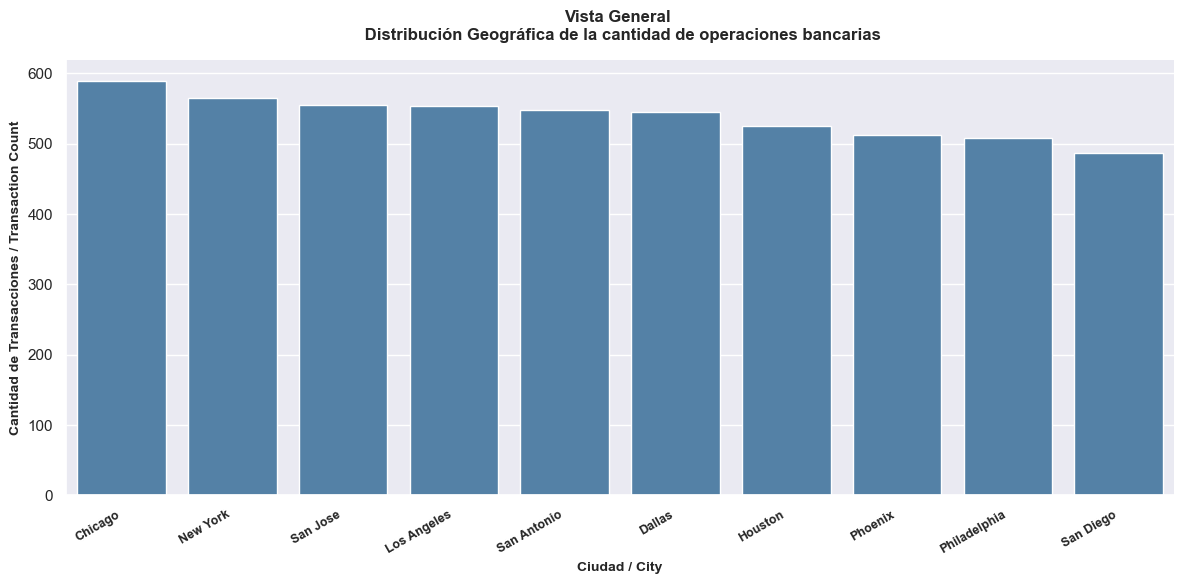

In [11]:
#
plt.figure(figsize=(12, 6))

#
orden_ciudades = df_bancos['City'].value_counts().index
sns.countplot(data=df_bancos, x="City", order=orden_ciudades, color="#4682B4")

#
plt.title('Vista General \n Distribución Geográfica de la cantidad de operaciones bancarias',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Ciudad / City', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

#
plt.xticks(rotation=30, ha='right', fontsize=9, fontweight='bold')

#
sns.despine()

plt.tight_layout()
plt.show()

In [13]:
#
balances_ordenados = df_bancos['Account_Balance'].sort_values(ascending=False)

# clientes que representan el 20% superior de la cartera
top_20_clientes = int(len(balances_ordenados) * 0.20)

# proporción de capital acumulado en ese grupo VIP
capital_total = balances_ordenados.sum()
capital_top_20 = balances_ordenados.iloc[:top_20_clientes].sum()
pct_concentracion = (capital_top_20 / capital_total) * 100

#
print("=" * 61)
print(f'Concentración de capital por cuentas bancarias')
# print("VISTA GENERAL - CONCENTRACIÓN DE CAPITAL")
print('=' * 61)
print(f"   Total de cuentas bancarias en la cartera :  {len(df_bancos):,}")
print(f"   Segmento 20% Superior                    :  {top_20_clientes:,} cuentas")
print(f"   Porcentaje de Concentración de Capital   :  {pct_concentracion:.2f}%")
print('.' * 61)

Concentración de capital por cuentas bancarias
   Total de cuentas bancarias en la cartera :  5,389
   Segmento 20% Superior                    :  1,077 cuentas
   Porcentaje de Concentración de Capital   :  35.58%
.............................................................


In [14]:
# print("""
# ==============================================================================
# CONCLUSIONES \nCONCENTRACIÓN DE CAPITAL
# ==============================================================================
#   Hallazgo de Negocio
#   El 20% de los clientes con los saldos más altos acumula
#   únicamente el 35.58% del capital total de la cartera transaccional.
# """)


**Cencentración de capital** -*Hallazgo de negocio*-  
<p align="justify">
Como puede observarse, el 35.58% del capital que administra la institución financiera en los saldos bancarios de sus clientes, proviene del 20% de las cuentas más altas; es decir, que un poco más de la tercera parte del capital total corresponde a la quinta parte de las cuentas aperturadas.
</p>

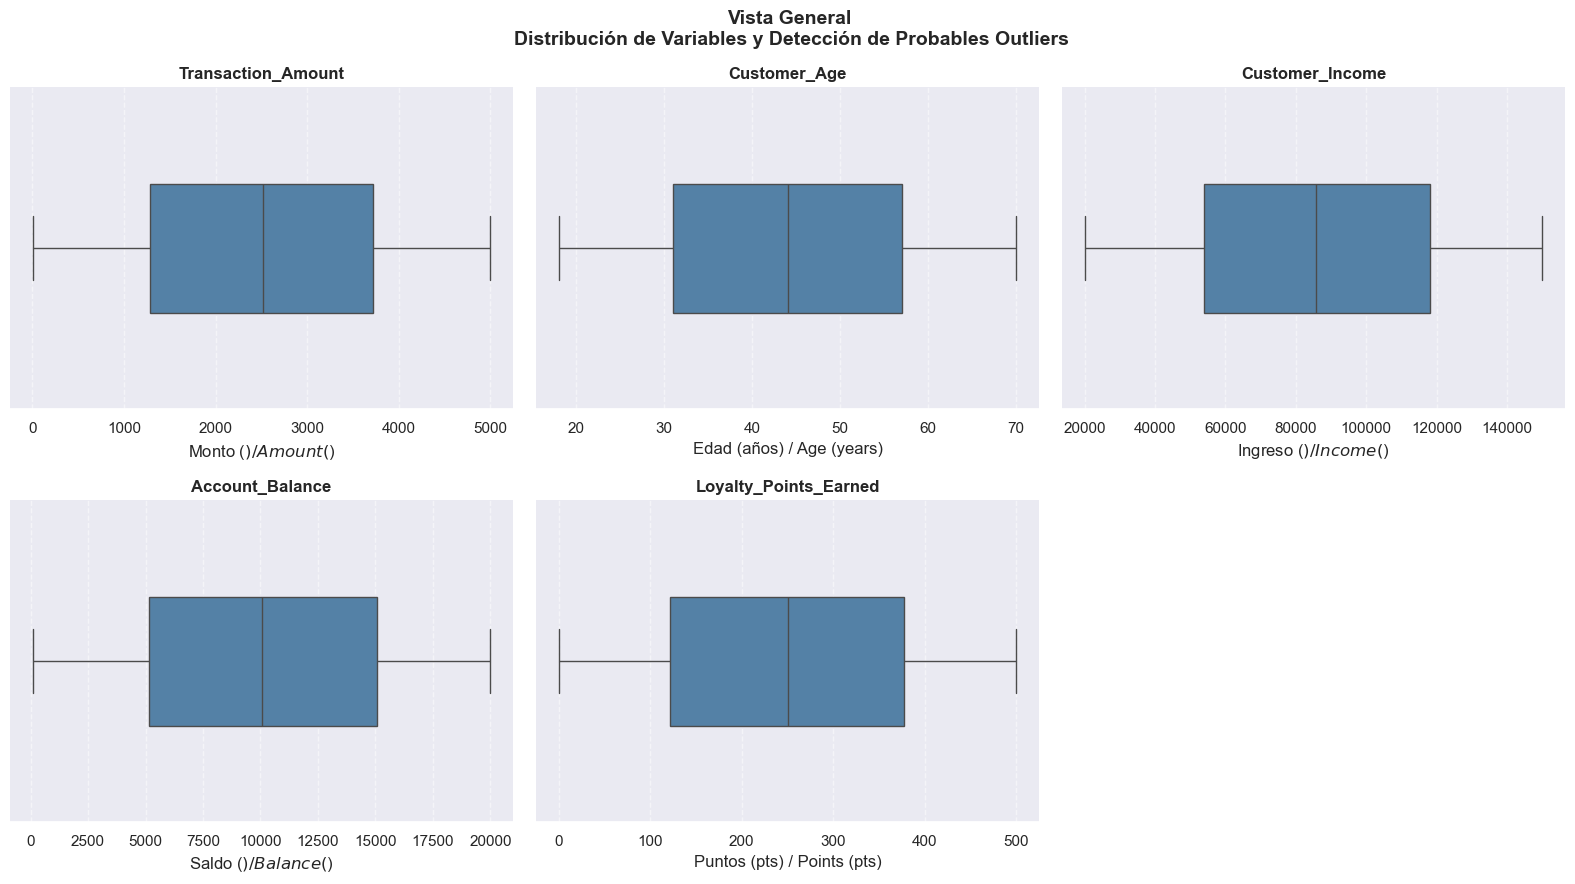

In [18]:

#
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Vista General \nDistribución de Variables y Detección de Probables Outliers',
             fontsize=14, fontweight='bold', y=0.98)

#
color_grafica = "#4682B4"

#
sns.boxplot(data=df_bancos, x="Transaction_Amount", ax=axes[0, 0], color=color_grafica, width=0.4)
axes[0, 0].set_title("Transaction_Amount", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Monto ($) / Amount ($)")

sns.boxplot(data=df_bancos, x="Customer_Age", ax=axes[0, 1], color=color_grafica, width=0.4)
axes[0, 1].set_title("Customer_Age", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Edad (años) / Age (years)")

sns.boxplot(data=df_bancos, x="Customer_Income", ax=axes[0, 2], color=color_grafica, width=0.4)
axes[0, 2].set_title("Customer_Income", fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel("Ingreso ($) / Income ($)")

sns.boxplot(data=df_bancos, x="Account_Balance", ax=axes[1, 0], color=color_grafica, width=0.4)
axes[1, 0].set_title("Account_Balance", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Saldo ($) / Balance ($)")

sns.boxplot(data=df_bancos, x="Loyalty_Points_Earned", ax=axes[1, 1], color=color_grafica, width=0.4)
axes[1, 1].set_title("Loyalty_Points_Earned", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Puntos (pts) / Points (pts)")

#
axes[1, 2].axis("off")

#
for i in range(2):
    for j in range(3):
        if not (i == 1 and j == 2):
            sns.despine(ax=axes[i, j], left=True)
            axes[i, j].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [19]:
# print("""
# ==============================================================================
# CONCLUSIONES \nVALORES ATÍPICOS
# ==============================================================================
#   Hallazgo de Negocio
#   Las medianas de las 5 variables numéricas se ubican exactamente en el centro
#   de las cajas y se detectan 0 registros atípicos (outliers).
# """)


**Comportamiento de las Variables y Valores Atípicos**   
<p align="justify">
Las gráficas exhibidas constatan que los valores de las variables numéricas registrados en la base de datos que se analiza, son muy regulares; es decir, que sus medianas se encuentran muy centradas en sus respectivos boxplots, sus cuartiles inferiores y superiores muy simétricos y sin detección de valores atípicos.
</p>

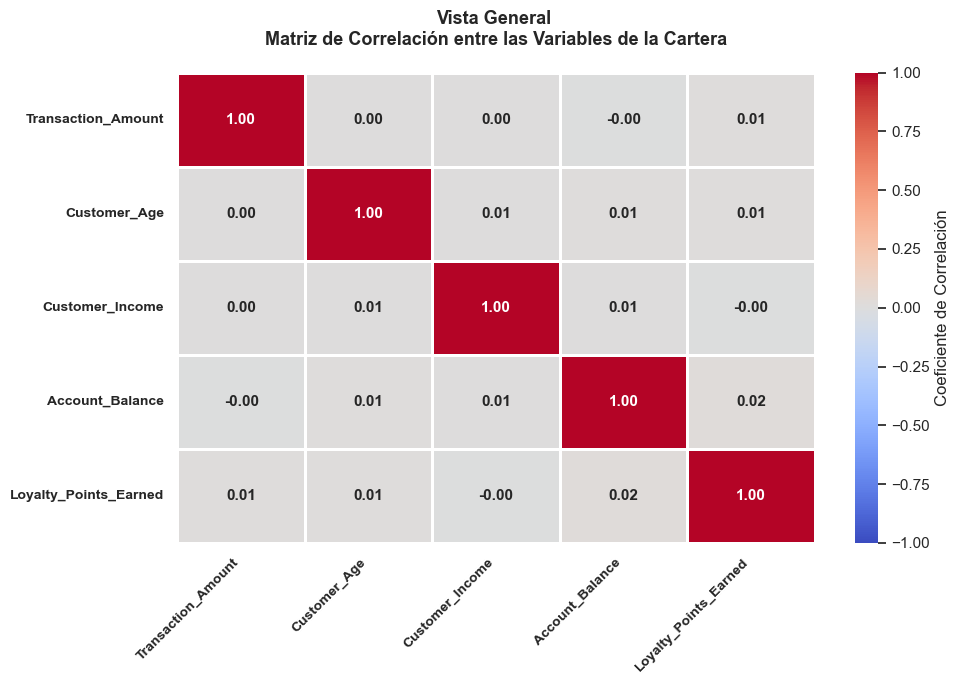

In [20]:

# correlación de Spearman para las 5 variables cuantitativas
columnas_num = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_corr = df_bancos[columnas_num].corr(method='spearman')

#
plt.figure(figsize=(10, 7))

# Graficar el mapa de calor
sns.heatmap(
    df_bancos_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.8,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Coeficiente de Correlación"},
    square=False,
    annot_kws={"size": 11, "fontweight": "bold"}
)

#
plt.title('Vista General \nMatriz de Correlación entre las Variables de la Cartera',
          fontsize=13, fontweight='bold', pad=20)

#
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [21]:
# print("""
# ==============================================================================
# CONCLUSIONES \nANÁLISIS DE CORRELACIÓN
# ==============================================================================
#   Hallazgo de Negocio
#   Todos los coeficientes de correlación fuera de la diagonal principal arrojan
#   valores nulos o cercanos a cero (0.00, 0.01, 0.02).
# """)


**Interdependencia entre las Variables de la Cartera**   
<p align="justify">
Esta gráfica de correlación, muestra que las variables numéricas de la cartera de cuentas bancarias presentan escasa o nula relación entre ellas. Las únicas variables que expresan un poco de asociación con otras son las de Account_Balance y Loyalty_Points_Earned. Como Hallazgo de negocio, vale la pena resaltar que la fidelidad de los clientes influye ligeramente en los saldos bancarios que se mantienen en las cuentas (0.02) y en los montos de las transferencias que se realizan (0.01), hecho que es recomendable incrementar y consolidar.   
</p>

In [25]:
#
percentiles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

# percentiles para las 5 columnas numéricas
columnas_num = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_percentiles = df_bancos[columnas_num].quantile(percentiles)

#
df_bancos_percentiles.index = [
    'Percentil 10 (P10)', 'Percentil 20 (P20)', 'Percentil 30 (P30)',
    'Percentil 40 (P40)', 'Percentil 50 (P50)', 'Percentil 60 (P60)',
    'Percentil 70 (P70)', 'Percentil 80 (P80)', 'Percentil 90 (P90)'
]

print("Reporte PERCENTILES de las Variables Numéricas")
print('.' * 46)

#
formatos_percentiles = {
    'Transaction_Amount': "${:,.2f}",
    'Customer_Income': "${:,.2f}",
    'Account_Balance': "${:,.2f}",
    'Customer_Age': "{:.1f}",
    'Loyalty_Points_Earned': "{:,.1f}"
}

df_bancos_percentiles.style.format(formatos_percentiles)


Reporte PERCENTILES de las Variables Numéricas
..............................................


,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
Percentil 10 (P10),$519.45,23.0,"$33,445.10","$2,043.31",49.0
Percentil 20 (P20),"$1,017.71",28.0,"$47,541.39","$4,115.05",98.0
Percentil 30 (P30),"$1,519.80",33.0,"$60,243.90","$6,257.16",148.0
Percentil 40 (P40),"$2,019.48",39.0,"$73,394.66","$8,326.80",198.0
Percentil 50 (P50),"$2,521.67",44.0,"$85,636.38","$10,077.78",251.0
Percentil 60 (P60),"$3,013.97",49.0,"$99,216.63","$12,136.19",300.0
Percentil 70 (P70),"$3,480.21",55.0,"$111,758.55","$14,064.19",352.6
Percentil 80 (P80),"$3,967.22",60.0,"$124,205.44","$16,030.41",403.0
Percentil 90 (P90),"$4,476.50",65.0,"$137,448.35","$17,928.00",451.0


In [27]:
#
cuartiles = [0.25, 0.50, 0.75]

# cuartiles para las 5 columnas numéricas
columnas_numericas = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_cuartiles = df_bancos[columnas_numericas].quantile(cuartiles)

#
df_bancos_cuartiles.index = [
    'Cuartil 1 (Q1)',
    'Cuartil 2 (Q2/Mediana)',
    'Cuartil 3 (Q3)'
]

print("Reporte CUARTILES de las Variables Numéricas")
print('.' * 44)

#
formatos_cuartiles = {
    'Transaction_Amount': "${:,.2f}",
    'Customer_Income': "${:,.2f}",
    'Account_Balance': "${:,.2f}",
    'Customer_Age': "{:.1f}",
    'Loyalty_Points_Earned': "{:,.1f}"
}

df_bancos_cuartiles.style.format(formatos_cuartiles)


Reporte CUARTILES de las Variables Numéricas
............................................


,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
Cuartil 1 (Q1),"$1,283.34",31.0,"$53,809.80","$5,159.45",122.0
Cuartil 2 (Q2/Mediana),"$2,521.67",44.0,"$85,636.38","$10,077.78",251.0
Cuartil 3 (Q3),"$3,715.92",57.0,"$118,092.64","$15,076.01",377.0


In [37]:
# Rango Intercuartílico (IQR) para los Montos de Transacción
Q1 = df_bancos['Transaction_Amount'].quantile(0.25)
Q3 = df_bancos['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

# límites estadísticos de control
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar e identificar si existen transacciones atípicas
outliers = df_bancos[(df_bancos['Transaction_Amount'] < limite_inferior) | (df_bancos['Transaction_Amount'] > limite_superior)]

print("=" * 66)
print("Diagnóstico de VALORES ATÍPICOS (Outliers) para Transaction_Amount")
print('=' * 66)
print()
print('Rango Intercuantil')
# print("DIAGNÓSTICO DE VALORES ATÍPICOS (OUTLIERS) \nRANGO INTERCUANTIL")
print()
print(f"   Límite Inferior para considerar Outlier :  ${limite_inferior:,.2f}")
print(f"   Límite Superior para considerar Outlier :  ${limite_superior:,.2f}")
print(f"   Total de registros fuera de límites     :   {len(outliers)}")
print('.' * 66)


Diagnóstico de VALORES ATÍPICOS (Outliers) para Transaction_Amount

Rango Intercuantil

   Límite Inferior para considerar Outlier :  $-2,365.53
   Límite Superior para considerar Outlier :  $7,364.79
   Total de registros fuera de límites     :   0
..................................................................


# Análisis Específico y Selección de Variables

Generar un subconjunto de datos ('subset_bancos'), limpiar los nombres de las columnas y seleccionar únicamente las variables que puedan ser de interés para el análisis:

* **Monto:** 'Transaction_Amount'
* **Perfil:** 'Transaction_Type', 'Customer_Age', 'Customer_Gender'
* **Control:** 'Transaction_Status', 'Fraud_Flag', 'City'

In [42]:
# ENFOQUES ESPECÍFICOS - CREACIÓN DE SUBSET DE INTERÉS

subset_bancos = df_bancos.copy()

# limpiar espacios en blanco residuales en los nombres de las columnas
subset_bancos.columns = subset_bancos.columns.str.strip()

#
columnas_subset = [
    'Transaction_Amount',
    'Transaction_Type',
    'Customer_Age',
    'Customer_Gender',
    'Transaction_Status',
    'Fraud_Flag',
    'City'
]

subset_bancos = subset_bancos[columnas_subset]

#
print('=' * 38)
print("SUBSET de Variables de Interés")
print("=" * 38)
print(f"Variables seleccionadas        : {len(columnas_subset)}")
print(f"Registros listos para análisis : {len(subset_bancos):,}")
print('.' * 38)

subset_bancos

SUBSET de Variables de Interés
Variables seleccionadas        : 7
Registros listos para análisis : 5,389
......................................


,Transaction_Amount,Transaction_Type,Customer_Age,Customer_Gender,Transaction_Status,Fraud_Flag,City
0,3198.94,Debit,55,Others,Failed,No,Phoenix
1,129.93,Credit,26,Others,Pending,Yes,Philadelphia
2,1378.77,Credit,29,Others,Failed,Yes,New York
3,1119.94,Credit,60,Male,Failed,Yes,Dallas
4,3683.67,Credit,29,Others,Failed,Yes,San Jose
...,...,...,...,...,...,...,...
5384,842.16,Credit,20,Male,Pending,Yes,Phoenix
5385,1996.73,Credit,28,Male,Failed,Yes,Phoenix
5386,1510.33,Debit,23,Male,Success,No,Dallas
5387,3732.02,Debit,40,Female,Success,Yes,Chicago


In [46]:
# indicadores de forma y distribución
sesgo = subset_bancos['Transaction_Amount'].skew()
curtosis = subset_bancos['Transaction_Amount'].kurtosis()

# cuartiles y el Rango Intercuartílico (IQR)
Q1 = subset_bancos['Transaction_Amount'].quantile(0.25)
Q3 = subset_bancos['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

# Límites de Control Estadístico
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar y buscar transacciones atípicas
outliers = subset_bancos[(subset_bancos['Transaction_Amount'] < limite_inferior) |
                         (subset_bancos['Transaction_Amount'] > limite_superior)]

#
print("="*50)
print("Auditoría Numérica Completa a 'Transaction_Amount'")
print("="*50)
print(f"   - Asimetría (Sesgo)             : {sesgo:.4f}   ")
print(f"   - Curtosis                      : {curtosis:.4f}")
print("."*50)
print(f"   - Primer Cuartil (Q1)           : ${Q1:,.2f}")
print(f"   - Tercer Cuartil (Q3)           : ${Q3:,.2f}")
print(f"   - Rango Intercuartílico (IQR)   : ${IQR:,.2f}")
print(f"   - Límite de Control Inferior    : ${limite_inferior:,.2f}")
print(f"   - Límite de Control Superior    : ${limite_superior:,.2f}")
print("."*50)
print(f"   - Registros atípicos detectados : {len(outliers)}")
print('.'*50)

Auditoría Numérica Completa a 'Transaction_Amount'
   - Asimetría (Sesgo)             : -0.0039   
   - Curtosis                      : -1.1781
..................................................
   - Primer Cuartil (Q1)           : $1,283.34
   - Tercer Cuartil (Q3)           : $3,715.92
   - Rango Intercuartílico (IQR)   : $2,432.58
   - Límite de Control Inferior    : $-2,365.53
   - Límite de Control Superior    : $7,364.79
..................................................
   - Registros atípicos detectados : 0
..................................................


Visualización del análisis realizado
....................................


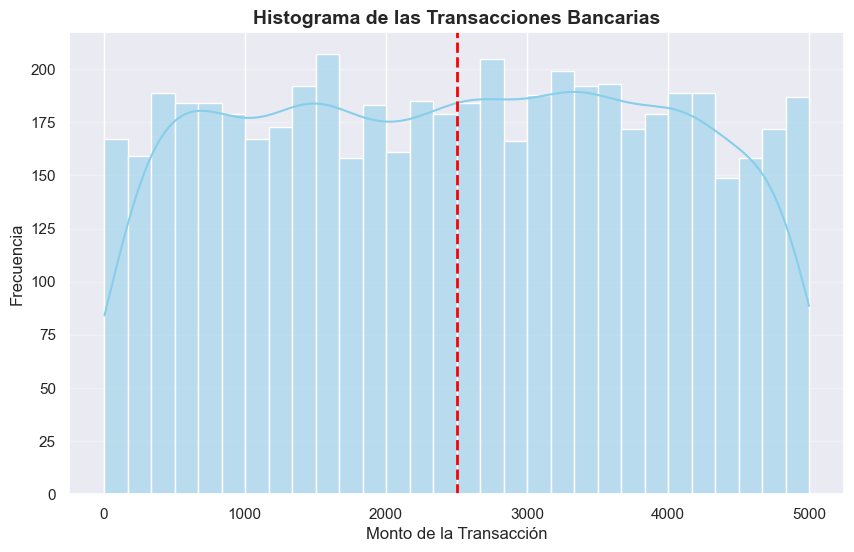

In [55]:
print('Visualización del análisis realizado')
print('.'*36)

plt.figure(figsize=(10, 6))

sns.histplot(data=subset_bancos, x='Transaction_Amount', kde=True, color='skyblue', bins=30)

media_monto = subset_bancos['Transaction_Amount'].mean()
plt.axvline(media_monto, color='red', linestyle='--', linewidth=2, label=f'Media: {media_monto:.2f}')

plt.title('Histograma de las Transacciones Bancarias', fontsize=14, fontweight='bold')
plt.xlabel('Monto de la Transacción', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.show()

**Interpretación del análisis efectuado a 'Transaction_Amount'**   
<p align="justify">
Los resultados de la auditoría numérica, que se validan en la representación gráfica, exhiben un comportamiento muy uniforme (que no es usual para datos financieros reales). El sesgo de -0.0039 indica que la distribución es altamente simétrica con respecto a la media -sin inclinación relevante hacia los extremos-, y el valor negativo de la curtosis de -1.1781 expresa que la curva de distribución es más plana que una normal, confirmándose también la ausencia de valores atípicos. 
</p>

In [61]:
# Efectur el cruce del indicador de fraude con el volumen y monto de las transacciones
analisis_fraude = subset_bancos.groupby('Fraud_Flag')['Transaction_Amount'].agg(['count', 'mean', 'min', 'max'])

print("Análisis de Riesgo de Fraude")
print('.'*28)
analisis_fraude.style.format({"mean": "${:,.2f}", "min": "${:,.2f}", "max": "${:,.2f}", "count": "{:,.0f}"})


Análisis de Riesgo de Fraude
............................


,count,mean,min,max
Fraud_Flag,,,,
No,"2,732","$2,502.38",$5.46,"$4,999.54"
Yes,"2,657","$2,506.98",$5.92,"$4,998.03"


In [62]:
#
# print("""
# ==============================================================================
# CONCLUSIONES \nANÁLISIS DE RIESGO DE FRAUDE
# ==============================================================================
#   Hallazgo de Negocio: Las transacciones legítimas (No) promedian $2,502.38
#   frente a $2,506.98 de las fraudulentas (Yes). Los mínimos y máximos son muy
#   cercanos

#   Interpretación Estadística: El monto de la operación no es un factor
#   discriminante para identificar fraudes.
# """)

**Interpretación del análisis del Riesgo de Fraude**   
<p align="justify">
El análisis de esta variable refleja otra situación de ALTA PREOCUPACIÓN para la institución bancaria, puesto que el 49.30% de las transacciones que se procesan RESULTAN SER FRAUDULENTAS; razón por la cual se debe actuar inmediatamente en la instrumentación de mecanismos de seguridad que disminuyan drástica y prontamente la incidencia de estos eventos que, además, se suscitan por igual para cualquier nivel de importe de transacciones, como lo expresa la media encontrada (lo que anula la efectividad de los sistemas tradicionales de alerta basados tan solo en reglas fijas de montos relevantes).
</p>

Comprobación visual del Riesgo de Fraude computado
...................................................


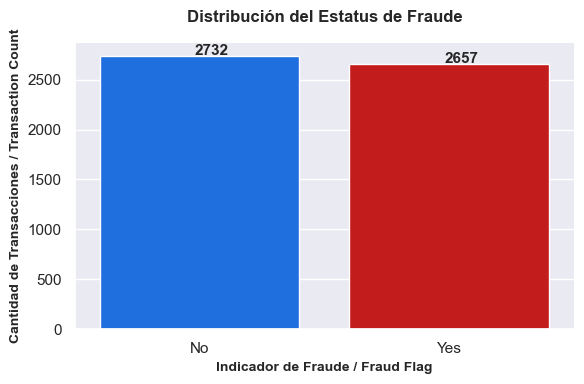

In [71]:
#
print('Comprobación visual del Riesgo de Fraude computado')
print('.'*51)

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(data=subset_bancos, x="Fraud_Flag", ax=ax, palette=["#006AFF", "#DF0000"])

for p in ax.patches:
    patch_height = p.get_height()
    ax.annotate(f'{int(patch_height)}',
                (p.get_x() + 0.38, patch_height + 10),
                fontsize=11, fontweight='bold')

#
plt.title('Distribución del Estatus de Fraude', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Indicador de Fraude / Fraud Flag', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.show()


In [77]:
# ANTE LA EVIDENCIA ANTERIOR, PARECE QUE ESTA COMPARATIVA YA NO ES NECESARIA



# plt.figure(figsize=(10, 6))

# # histograma superpuesto por estatus de fraude con curva KDE
# sns.histplot(data=subset_bancos, x="Transaction_Amount", hue="Fraud_Flag", kde=True, bins=30, palette="Set1", alpha=0.5)

# #
# plt.title("COMPARACIÓN DE DISTRIBUCIÓN DE MONTOS \nNORMAL VS FRAUDE",
#           fontsize=12, fontweight='bold', pad=15)
# plt.xlabel("Monto de la Transacción ($)", fontsize=10, fontweight='bold')
# plt.ylabel("Frecuencia / Frequency", fontsize=10, fontweight='bold')

# #
# sns.despine()

# plt.tight_layout()
# plt.show()


In [72]:

# print("""
# ==============================================================================
# HALLAZGO VISUAL \nEMPALME DE DISTRIBUCIONES
# ==============================================================================
#   Hallazgo de Negocio: El histograma comparativo revela un empalme casi perfecto
#   entre las barras rojas (Legítimas) y azules (Fraude) a lo largo de todo el
#   espectro económico (desde $0 hasta $5,000).

#   Interpretación Estadística: Ambas curvas de tendencia estimada (KDE) viajan de
#   forma paralela e idéntica. Esto aporta la evidencia visual definitiva de que
#   los eventos de fraude no se concentran en montos pequeños ni en compras grandes;
#   el patrón de ataque imita con precisión el comportamiento de consumo normal de
#   la cartera, lo que anula la efectividad de los sistemas tradicionales de alerta
#   basados únicamente en reglas fijas de montos
# """)


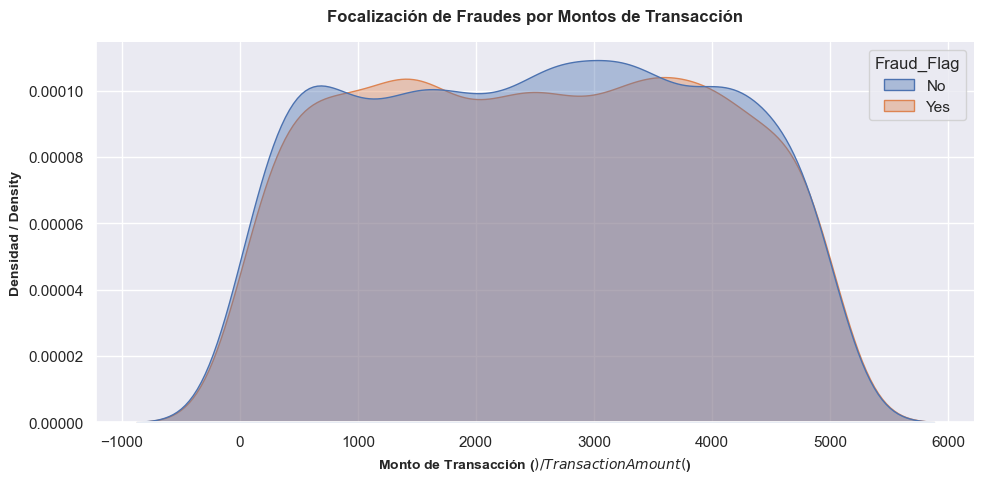

In [113]:
# Focalización de Fraudes por Montos de Transacción
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=subset_bancos,
    x="Transaction_Amount",
    hue="Fraud_Flag",
    fill=True,
    alpha=0.4
)

plt.title('Focalización de Fraudes por Montos de Transacción',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.show()


In [116]:
# Análisis Inferencial
monto_legit = subset_bancos[subset_bancos['Fraud_Flag'] == 'No']['Transaction_Amount']
monto_fraud = subset_bancos[subset_bancos['Fraud_Flag'] == 'Yes']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_legit, monto_fraud, alternative='two-sided')

#
print("=" * 78)
print("PRUEBA INFERENCIAL - Monto de Transacciones vs Operaciones Fraudulentas")
print("=" * 78)
print(f"   - Estadístico U / U Statistic: {stat:,.1f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("." * 78)

if p_value < 0.05:
    print("   - Conclusión\n     Rechazo H0. Los montos cambian significativamente en situaciones de fraude.")
else:
    print("   - Conclusión\n     No rechazo H0. No hay diferencia estadística en el monto de ambos grupos.")

print("." * 78)

PRUEBA INFERENCIAL - Monto de Transacciones vs Operaciones Fraudulentas
   - Estadístico U / U Statistic: 3,622,833.0
   - p-valor / p-value: 0.9076
..............................................................................
   - Conclusión
     No rechazo H0. No hay diferencia estadística en el monto de ambos grupos.
..............................................................................


Confirmación del nivel de Riesgo de Fraude, segmentado por ciudad
.................................................................


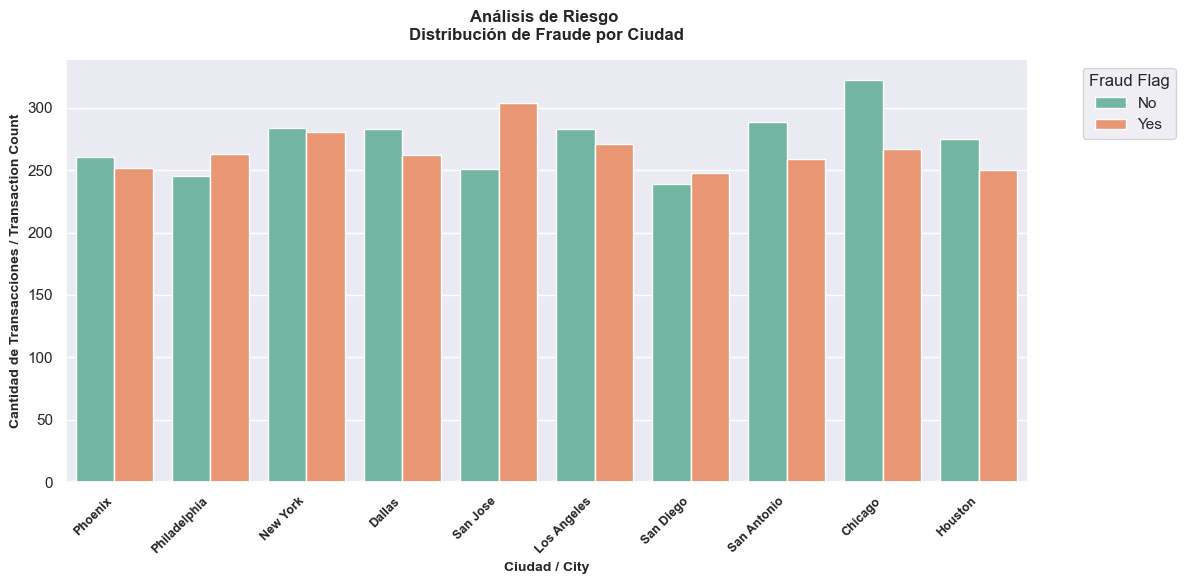

In [76]:
# Relación del análisis de riesgo por ciudad
print('Confirmación del nivel de Riesgo de Fraude, segmentado por ciudad')
print('.'*65)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=subset_bancos,
    x='City',
    hue='Fraud_Flag',
    palette='Set2'
)

plt.title('Análisis de Riesgo \nDistribución de Fraude por Ciudad',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Ciudad / City', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=9, fontweight='bold')

plt.legend(title='Fraud Flag', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()

plt.tight_layout()
plt.show()

In [78]:
# ANTE LA EVIDENCIA ANTERIOR, PARECE QUE ESTA COMPARATIVA YA NO ES NECESARIA



# #
# plt.figure(figsize=(10, 5))

# #
# sns.kdeplot(
#     data=subset_bancos,
#     x="Transaction_Amount",
#     hue="Fraud_Flag",
#     fill=True,
#     alpha=0.4
# )

# #
# plt.title('COMPARACIÓN DE MONTOS POR ESTATUS DE FRAUDE',
#           fontsize=12, fontweight='bold', pad=15)
# plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
# plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

# #
# sns.despine()

# plt.tight_layout()
# plt.show()

In [83]:
grupo_0 = subset_bancos[subset_bancos["Fraud_Flag"] == 'Yes']["Transaction_Amount"]
grupo_1 = subset_bancos[subset_bancos["Fraud_Flag"] == 'No']["Transaction_Amount"]

# prueba de Levene para homogeneidad de varianzas
stat, p_value = levene(grupo_0, grupo_1)

#
print("Prueba de Homocedasticidad - Levene")
print("=" * 84)
print(f"   - Estadístico Levene / Levene Statistic: {stat:.4f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("." * 84)

if p_value > 0.05:
    print("   - Conclusión\n     No se rechaza H0. Las varianzas pueden considerarse iguales (Homocedasticidad).")
else:
    print("   - Conclusión\n     Se rechaza H0. Existen diferencias significativas entre las varianzas.")

print("." * 84)


Prueba de Homocedasticidad - Levene
   - Estadístico Levene / Levene Statistic: 0.0296
   - p-valor / p-value: 0.8635
....................................................................................
   - Conclusión
     No se rechaza H0. Las varianzas pueden considerarse iguales (Homocedasticidad).
....................................................................................


**Interpretación de la prueba**   
<p align="justify">
El resultado de esta prueba confirma que el nivel de riesgo permanecerá si no se propicia una solución inmediata, aunque -a la vez- manifiesta que un modelo que se base en este comportamiento permitirá proponer soluciones estadísticamente confiables.
</p>

In [85]:
# tabla de frecuencias relativas cruzando Género y Fraude
cruze_genero = pd.crosstab(subset_bancos['Customer_Gender'], subset_bancos['Fraud_Flag'], normalize='index') * 100

print("Focalización de la Tasa de Fraude por Género")
print('.'*44)
cruze_genero.style.format("{:.2f}%")


Focalización de la Tasa de Fraude por Género
............................................


Fraud_Flag,No,Yes
Customer_Gender,,
Female,51.43%,48.57%
Male,50.40%,49.60%
Others,50.25%,49.75%


In [89]:
#
print("""
======================================================================================
Conclusiones
======================================================================================
  La tasa de riesgo de fraude se distribuye de manera similar por género.

  Interpretación Estadística: el género de los clientes no proporciona información
  predictiva o de correlación sobre la vulnerabilidad en las transacciones efectuadas.
""")


Conclusiones
  La tasa de riesgo de fraude se distribuye de manera similar por género.

  Interpretación Estadística: el género de los clientes no proporciona información
  predictiva o de correlación sobre la vulnerabilidad en las transacciones efectuadas.



In [102]:
# tabla de contingencia porcentual cruzando Tipo de Transacción y Fraude
cruze_tarjetas = pd.crosstab(subset_bancos['Transaction_Type'], subset_bancos['Fraud_Flag'], normalize='index') * 100

print("Focalización de la Tasa de Fraude por Tipo de Transacción")
print('.'*57)
cruze_tarjetas.style.format("{:.2f}%")

Focalización de la Tasa de Fraude por Tipo de Transacción
.........................................................


Fraud_Flag,No,Yes
Transaction_Type,,
Credit,50.50%,49.50%
Debit,50.89%,49.11%


In [111]:
#
print('='*97)
print("ANÁLISIS ESTADÍSTICO INFERENCIAL -Transaction_Type vs. Fraud_Flag")
print('='*97)

# PRUEBA DE CHI-CUADRADO (Variables Categóricas) ---
# tabla de frecuencias absolutas para la prueba
tabla_chi = pd.crosstab(subset_bancos['Transaction_Type'], subset_bancos['Fraud_Flag'])
chi2, p_val_chi, dof, expected = chi2_contingency(tabla_chi) 

print("1. Prueba de Chi-Cuadrado (Transaction_Type vs Fraud_Flag)")
print(f"   - Estadístico Chi2: {chi2:.4f}")
print(f"   - p-valor (p-value): {p_val_chi:.4f}")
if p_val_chi < 0.05:
    print("   - Resultado: Rechazo H0. El fraude DEPENDEN del tipo de tarjeta (Significativo).")
else:
    print("   - Resultado: No rechazo H0. El fraude y el tipo de tarjeta son INDEPENDIENTES.")
print()

# PRUEBA U DE MANN-WHITNEY (Variables Numéricas entre 2 Grupos) ---
# Separar los montos de transacciones legítimas y fraudes
monto_legit = subset_bancos[subset_bancos['Fraud_Flag'] == 'No']['Transaction_Amount']
monto_fraud = subset_bancos[subset_bancos['Fraud_Flag'] == 'Yes']['Transaction_Amount']

stat_u, p_val_u = mannwhitneyu(monto_legit, monto_fraud, alternative='two-sided')

print("2. Prueba U de Mann-Whitney (Transaction_Amount vs Fraud_Flag)")
print(f"   - Estadístico U: {stat_u:,}")
print(f"   - p-valor (p-value): {p_val_u:.4f}")
if p_val_u < 0.05:
    print("   - Resultado: Rechazo H0. Los montos cambian significativamente en situaciones de fraude.")
else:
    print("   - Resultado: No rechazo H0. No hay diferencia estadística en los montos de ambos grupos.")
print()

# PRUEBA DE KRUSKAL-WALLIS (Montos vs Categorías Múltiples)
print("3. Prueba de Kruskal-Wallis (Montos vs Categorías Múltiples)")

# Agrupar los montos de transacciones por cada tipo de estatus operativo
grupos_status = [df[1] for df in subset_bancos.groupby('Transaction_Status')['Transaction_Amount']]

# Ejecutar la prueba de hipótesis
stat_k, p_val_k = kruskal(*grupos_status)

print(f"   - Estadístico H: {stat_k:.4f}")
print(f"   - p-valor (p-value): {p_val_k:.4f}")
if p_val_k < 0.05:
    print("   - Resultado: Rechazo H0. El estado de la transacción influye en el monto de dinero.")
else:
    print("   - Resultado: No rechazo H0. El monto de la transacción es independiente del estatus operativo.")

print('.'*97)

ANÁLISIS ESTADÍSTICO INFERENCIAL -Transaction_Type vs. Fraud_Flag
1. Prueba de Chi-Cuadrado (Transaction_Type vs Fraud_Flag)
   - Estadístico Chi2: 0.0644
   - p-valor (p-value): 0.7997
   - Resultado: No rechazo H0. El fraude y el tipo de tarjeta son INDEPENDIENTES.

2. Prueba U de Mann-Whitney (Transaction_Amount vs Fraud_Flag)
   - Estadístico U: 3,622,833.0
   - p-valor (p-value): 0.9076
   - Resultado: No rechazo H0. No hay diferencia estadística en los montos de ambos grupos.

3. Prueba de Kruskal-Wallis (Montos vs Categorías Múltiples)
   - Estadístico H: 0.4021
   - p-valor (p-value): 0.8179
   - Resultado: No rechazo H0. El monto de la transacción es independiente del estatus operativo.
.................................................................................................


**Conclusión del análisis al riesgo de fraude en las transacciones**   
<p align="justify">
Los hallazgos encontrados en el alto volumen de transacciones fraudulentas y la busqueda sin éxito de correlaciones significativas, permiten reconocer (y demostrar matemáticamente) que las practicas fraudulentas no tienen un patrón específico y que se realizan sin distinción alguna entre montos, ciudades, género o tipo de transacción; lo que conlleva a plantear soluciones que consideren la totalidad de los procesos operativos de la institución bancaria.
</p>

In [ ]:
# PARA UNA MEJOR INTERPRETACIÓN DEL DOCUMENTO SE TRASLADÓ A UNA SECCIÓN ANTERIOR



# plt.figure(figsize=(10, 6))

# # Graficar el histograma general de montos usando tu variable subset_bancos
# sns.histplot(data=subset_bancos, x='Transaction_Amount', color='purple', kde=True, bins=30)

# plt.title('Distribución Global de Montos de Transacción')
# plt.xlabel('Monto de Transacción ($)')
# plt.ylabel('Frecuencia Absoluta')
# plt.show()


In [92]:
# tabla cruzada de porcentajes entre Ciudad y Estado de la Transacción
friccion_regional = pd.crosstab(subset_bancos['City'], subset_bancos['Transaction_Status'], normalize='index') * 100

print("Análisis del Estatus de las Transacciones por ciudad")
print('.'*52)
friccion_regional.style.format("{:.2f}%")


Análisis del Estatus de las Transacciones por ciudad
....................................................


Transaction_Status,Failed,Pending,Success
City,,,
Chicago,32.77%,32.26%,34.97%
Dallas,33.76%,34.31%,31.93%
Houston,34.29%,34.48%,31.24%
Los Angeles,35.02%,29.60%,35.38%
New York,33.81%,32.57%,33.63%
Philadelphia,30.51%,34.65%,34.84%
Phoenix,33.14%,36.65%,30.21%
San Antonio,29.74%,34.67%,35.58%
San Diego,37.17%,34.29%,28.54%


In [93]:
#
# print("""
# ==============================================================================
# CONCLUSIONES \nOPERATIVA POR CIUDAD
# ==============================================================================
#   Hallazgo de Negocio
#   La tasa de transacciones fallidas (Failed) se mantiene de
#   manera homogénea flotando alrededor del 33% en absolutamente todas las ciudades
#   de la cartera (ej. Chicago 32.77%, dallas 33.76%, New York 33.81%).
# """)


**Análisis del Estatus de las Transacciones**   
<p align="justify">
Hallazgo de negocio.- Se confirma que la tasa de transacciones fallidas es homogenea en su distribución por ciudad, flotando en al rededor de la tercera parte de las transacciones locales totales.
</p>

In [95]:
# estadísticas descriptivas de la edad agrupadas por género
perfil_edad = subset_bancos.groupby('Customer_Gender')['Customer_Age'].agg(['count', 'mean', 'median', 'min', 'max'])

print("Focalización de Clientes por Perfil de Edad")
print('.'*43)
perfil_edad.style.format({"mean": "{:.1f} ", "median": "{:.0f}", "min": "{:.0f}", "max": "{:.0f}", "count": "{:,.0f}"})


Focalización de Clientes por Perfil de Edad
...........................................


,count,mean,median,min,max
Customer_Gender,,,,,
Female,"1,824",44.3,44,18,70
Male,"1,772",44.1,44,18,70
Others,"1,793",43.7,44,18,70


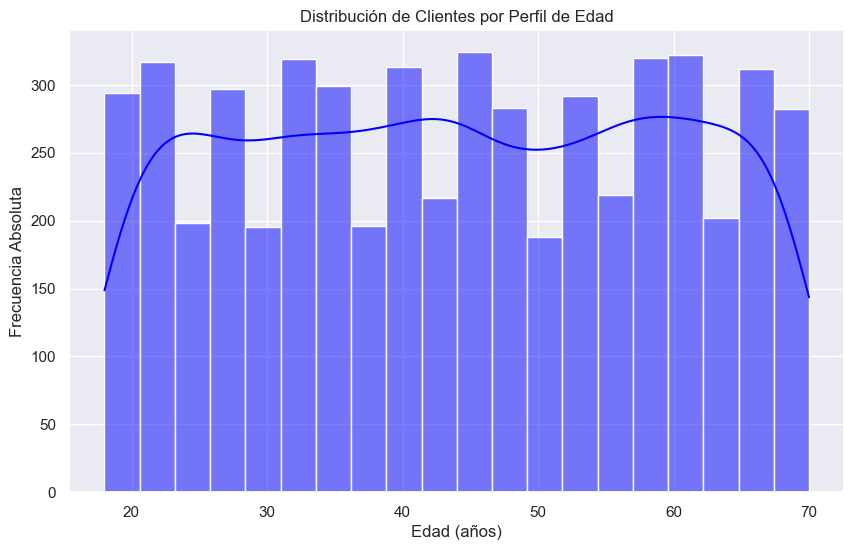

In [96]:
plt.figure(figsize=(10, 6))

# Graficar el histograma de distribución de edad
sns.histplot(data=subset_bancos, x='Customer_Age', color='blue', kde=True, bins=20)

plt.title('Distribución de Clientes por Perfil de Edad')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia Absoluta')
plt.show()

In [98]:
#
# print("""
# ==============================================================================
# CONCLUSIONES \nPERFILAMIENTO DEMOGRÁFICO DE EDAD
# ==============================================================================
#   Hallazgo de Negocio
#   El histograma de edades refleja una distribución uniforme
#   perfecta, donde la edad promedio (mean) y la mediana se ubican de manera idéntica
#   en los 44 años para mujeres, hombres y otros grupos de la población bancaria.

#   Interpretación Estadística
#   No existe una concentración comercial en segmentos
#   jóvenes o adultos mayores; la cartera tiene exactamente la misma presencia en
#   todos los rangos desde los 18 hasta los 70 años. Esta homogeneidad estructural
#   indica la ausencia de focos naturales de mercado
# """)

**Perfil de Edad de los Clientes**   
<p align="justify">
Hallazgo de negocio.- El histograma de edades refleja una distribución uniforme, donde la edad media y la mediana se ubican -ambas- en 44 años.  
  
Intepretación Estadística.- No existe una concentración comercial en segmentos de jóvenes o adultos mayores; la cartera tiene exactamente la misma presencia en todos los rangos de edad, desde los 18 hasta los 70 años. Esta homogeneidad estructural indica la ausencia de focos naturales de mercado.
</p>

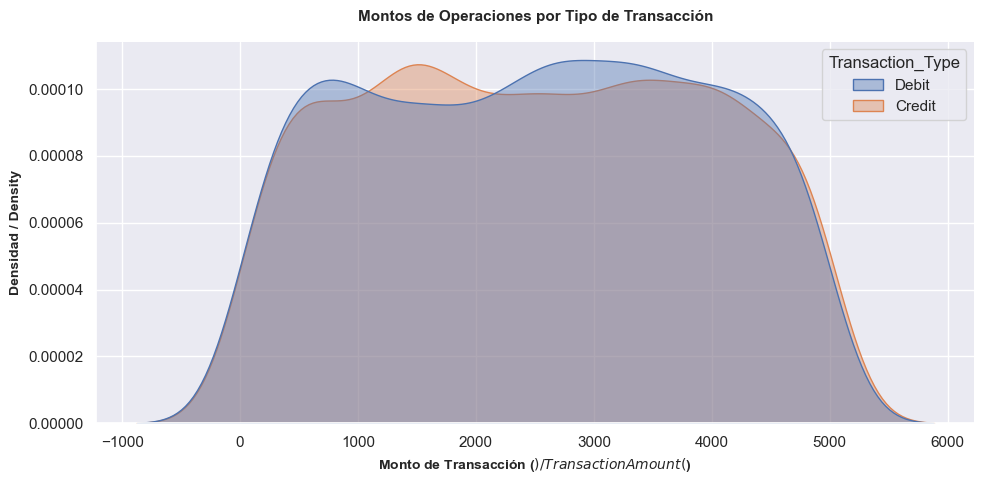

In [118]:
# Análisis de operaciones por tipo de transacción 
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=subset_bancos,
    x="Transaction_Amount",
    hue="Transaction_Type",
    fill=True,
    alpha=0.4
)

plt.title('Montos de Operaciones por Tipo de Transacción',
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.show()


**Operaciones por Tipo de Transacción**   
<p align="justify">
Hallazgo de negocio.- El tipo de transacción (tarjeta de débito o crédito) tampoco marca una tendencia preferente en el comportamiento de la demanda de servicio de los clientes.
</p>

In [121]:
# Filtrar los montos
monto_debit = subset_bancos[subset_bancos['Transaction_Type'] == 'Debit']['Transaction_Amount']
monto_credit = subset_bancos[subset_bancos['Transaction_Type'] == 'Credit']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_credit, monto_debit, alternative='two-sided')

#
print("PRUEBA INFERENCIAL - Comparativo por Tipo de Transacción")
print("=" * 83)
print(f"   - Estadístico U / U Statistic: {stat:,.1f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("." * 83)

if p_value < 0.05:
    print("   - Conclusión\n     Rechazo H0. El monto de transacción cambia significativamente según la tarjeta.")
else:
    print("   - Conclusión\n     No rechazo H0. El comportamiento del gasto es idéntico entre Débito y Crédito.")

print("." * 83)

PRUEBA INFERENCIAL - Comparativo por Tipo de Transacción
   - Estadístico U / U Statistic: 3,628,765.5
   - p-valor / p-value: 0.9817
...................................................................................
   - Conclusión
     No rechazo H0. El comportamiento del gasto es idéntico entre Débito y Crédito.
...................................................................................


In [124]:
#
print("""
====================================================================================
Conclusión - Prueba de Tipo de Transacción
====================================================================================
  Hallazgo de Negocio
    La prueba U de Mann-Whitney arrojó un p-valor de 0.9817,
    lo que confirma que no existe ninguna diferencia entre el dinero que gasta un
    cliente con tarjeta de débito frente a uno de crédito.

  Interpretación Estadística
    Al ser el p-valor drásticamente superior a 0.05,
    se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las
    poblaciones de ambas tarjetas comparten la misma distribución de gasto uniforme,
    validando el comportamiento homogéneo y simétrico del sistema transaccional.
....................................................................................
""")


Conclusión - Prueba de Tipo de Transacción
  Hallazgo de Negocio
    La prueba U de Mann-Whitney arrojó un p-valor de 0.9817,
    lo que confirma que no existe ninguna diferencia entre el dinero que gasta un
    cliente con tarjeta de débito frente a uno de crédito.

  Interpretación Estadística
    Al ser el p-valor drásticamente superior a 0.05,
    se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las
    poblaciones de ambas tarjetas comparten la misma distribución de gasto uniforme,
    validando el comportamiento homogéneo y simétrico del sistema transaccional.
....................................................................................



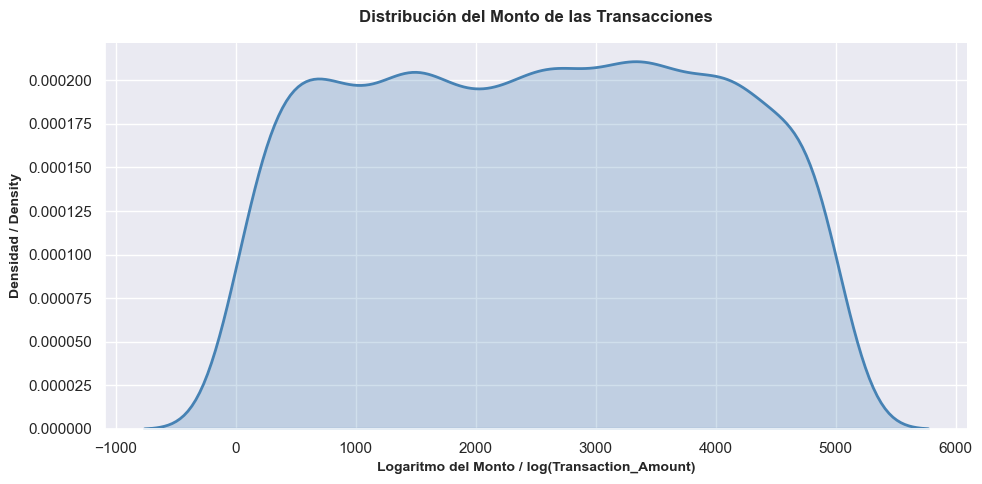

In [131]:
# Analisis Descriptivo de Transaction_Amount
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data = subset_bancos,
    x='Transaction_Amount',
    fill=True,
    color="#4682B4",
    linewidth=2
)

plt.title('Distribución del Monto de las Transacciones',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Logaritmo del Monto / log(Transaction_Amount)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.show()


In [142]:
#
media_real = subset_bancos['Transaction_Amount'].mean()
desv_real = subset_bancos['Transaction_Amount'].std()

# prueba de Bondad de Ajuste estimando los parámetros correspondientes
tran_gof = stats.goodness_of_fit(
    stats.norm,
    subset_bancos['Transaction_Amount'],
    statistic='ks',
    fit_params={'loc': media_real, 'scale': desv_real}
)

print("=" * 73)
print("PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov- para Transaction_Amount")
print("=" * 73)
print()
print("¿ La Distribución es Normal ?")
print()
print(f"   - Media Estimada      : ${media_real:,.2f}")
print(f"   - Desviación Estándar : ${desv_real:,.2f}")
print()
print(f"   - Estadístico KS      : {tran_gof.statistic:.4f}")
print(f"   - p-value             : {tran_gof.pvalue:.4f}")
print("." * 73)

if tran_gof.pvalue < 0.05:
    print("   - Conclusión\n     Se rechaza H0. Los montos NO siguen una distribución normal.")
else:
    print("   - Conclusión\n     No se rechaza H0. Los montos siguen una distribución normal.")

print("." * 73)


PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov- para Transaction_Amount

¿ La Distribución es Normal ?

   - Media Estimada      : $2,504.65
   - Desviación Estándar : $1,426.75

   - Estadístico KS      : 0.0571
   - p-value             : 0.0001
.........................................................................
   - Conclusión
     Se rechaza H0. Los montos NO siguen una distribución normal.
.........................................................................


In [136]:
# print("""
# ==============================================================================
# CONCLUSIONES \nPRUEBA DE NORMALIDAD
# ==============================================================================
#   Hallazgo de Negocio
#   La prueba de Kolmogorov-Smirnov arrojó un p-valor de 0.0001,
#   lo que rechaza de forma absoluta la hipótesis nula de normalidad (H0).

#   Interpretación Estadística
#   Este resultado valida científicamente lo observado en los histogramas planos.
# """)

**Prueba de Normalidad para Transaction_Amount**   
<p align="justify">
Hallazgo de negocio.- La prueba de Kolmogorov-Smirnov arrojó un p-value de 0.0001, lo que rechaza de forma absoluta la hipótesis nula de normalidad (H0).  
  
Intepretación Estadística.- Este resultado valida formalmente lo observado en los histogramas planos.
</p>

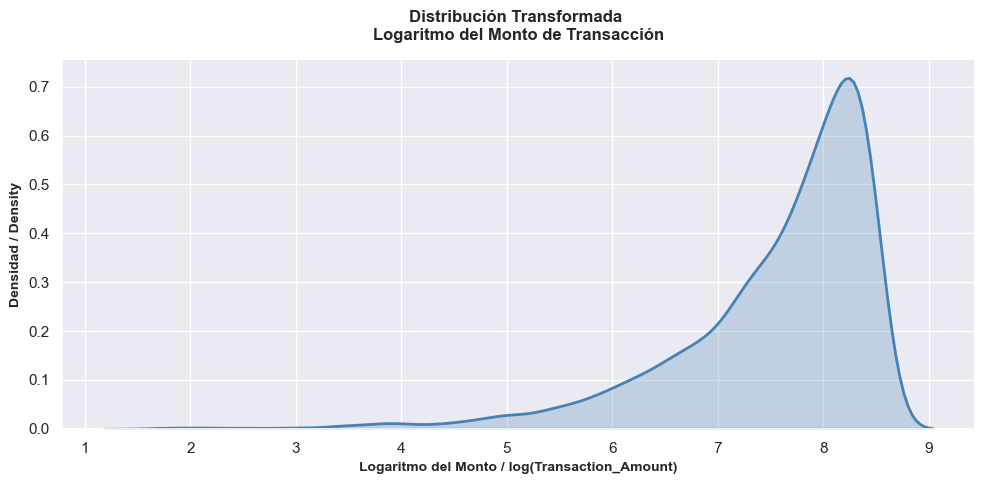

In [138]:
# Transformación Logarítmica 
subset_bancos['Log_Transaction_Amount'] = np.log(subset_bancos['Transaction_Amount'])

# Configurar el tamaño del lienzo proporcional
plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=subset_bancos,
    x="Log_Transaction_Amount",
    fill=True,
    color="#4682B4",
    linewidth=2
)

plt.title('Distribución Transformada \nLogaritmo del Monto de Transacción',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Logaritmo del Monto / log(Transaction_Amount)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.show()


In [141]:
#
# print("""
# ==============================================================================
# Análisis de la Transformación
# ==============================================================================
#   Hallazgo de Negocio
#   Al aplicar la transformación logarítmica (np.log) sobre
#   Transaction_Amount, los datos deforman su homogeneidad original, generando
#   una asimetría negativa (sesgo hacia la izquierda) concentrada entre los
#   valores transformados altos (8 y 9).
#   Interpretación Estadística
#   Previamente, el método IQR demostró la ausencia total de valores extremos
#   (0 outliers) en la cartera original, confirmando una distribución uniforme
#   simétrica entre $0 y $5,000. El resultado de este experimento demuestra que
#   la transformación logarítmica no es adecuada para variables uniformes, ya
#   que rompe la simetría perfecta de los montos en lugar de aproximarlos a una
#   campana de Gauss, empeorando el sesgo.
# """)


**Transformación de Transaction_Amount**   
<p align="justify">
Hallazgo de negocio.- Al aplicar la transformación logarítmica sobre 'Transaction_Amount', los datos deforman su homogeneidad original, generando una asimetría negativa (sesgo hacia la izquierda) concentrada entre los valores transformados más altos (8 y 9).  

Intepretación Estadística.- Previamente, el método IQR demostró la ausencia total de valores atípicos (0 outliers) en la cartera original, confirmando una distribución uniforme y simétrica entre $0 y $5,000. El resultado de este ejercicio demuestra que la transformación logarítmica no es adecuada para variables uniformes, ya que rompe la simetría inicial de los montos en lugar de aproximarlos a una campana de Gauss, generando un sesgo significativo; tal y como se comprueba en el análisis descriptivo siguiente.
</p>

In [148]:
print("=" * 74)
print("Transformación de datos y PRUEBA FORMAL DE NORMALIDAD -Kolmogorov-Smirnov-")
print("=" * 74)
print()
print("¿ La Distribución es Normal en Log_Transaction_Amount ?")
print()

# transformación logarítmica (Log Transform)
subset_bancos['Log_Transaction_Amount'] = np.log(subset_bancos['Transaction_Amount'])

# estandarizar los datos transformados para la prueba KS estándar N(0,1)
log_mean = subset_bancos['Log_Transaction_Amount'].mean()
log_std = subset_bancos['Log_Transaction_Amount'].std()
x_std = (subset_bancos['Log_Transaction_Amount'] - log_mean) / log_std

# calcular nuevos indicadores de forma (Sesgo y Curtosis post-transformación)
nuevo_sesgo = subset_bancos['Log_Transaction_Amount'].skew()
nueva_curtosis = subset_bancos['Log_Transaction_Amount'].kurtosis()

# prueba de Kolmogorov-Smirnov sobre los datos estandarizados
ks_stat, p_value = stats.kstest(x_std, 'norm')

print(f"   - Nuevo Sesgo    : {nuevo_sesgo:.4f}")
print(f"   - Nueva Curtosis : {nueva_curtosis:.4f}")
print()
print(f"   - Estadístico KS : {ks_stat:.4f}")
print(f"   - p-value        : {p_value:.4f}")
print("." * 74)

if p_value < 0.05:
    print("   - Conclusión:\n     Se rechaza H0. Incluso con la transformación logarítmica,\n     los datos NO siguen una distribución normal.")
else:
    print("   - Conclusión:\n     No se rechaza H0. La transformación normalizó los datos.")

print("." * 74)


Transformación de datos y PRUEBA FORMAL DE NORMALIDAD -Kolmogorov-Smirnov-

¿ La Distribución es Normal en Log_Transaction_Amount ?

   - Nuevo Sesgo    : -1.8670
   - Nueva Curtosis : 4.7085

   - Estadístico KS : 0.1532
   - p-value        : 0.0000
..........................................................................
   - Conclusión:
     Se rechaza H0. Incluso con la transformación logarítmica,
     los datos NO siguen una distribución normal.
..........................................................................


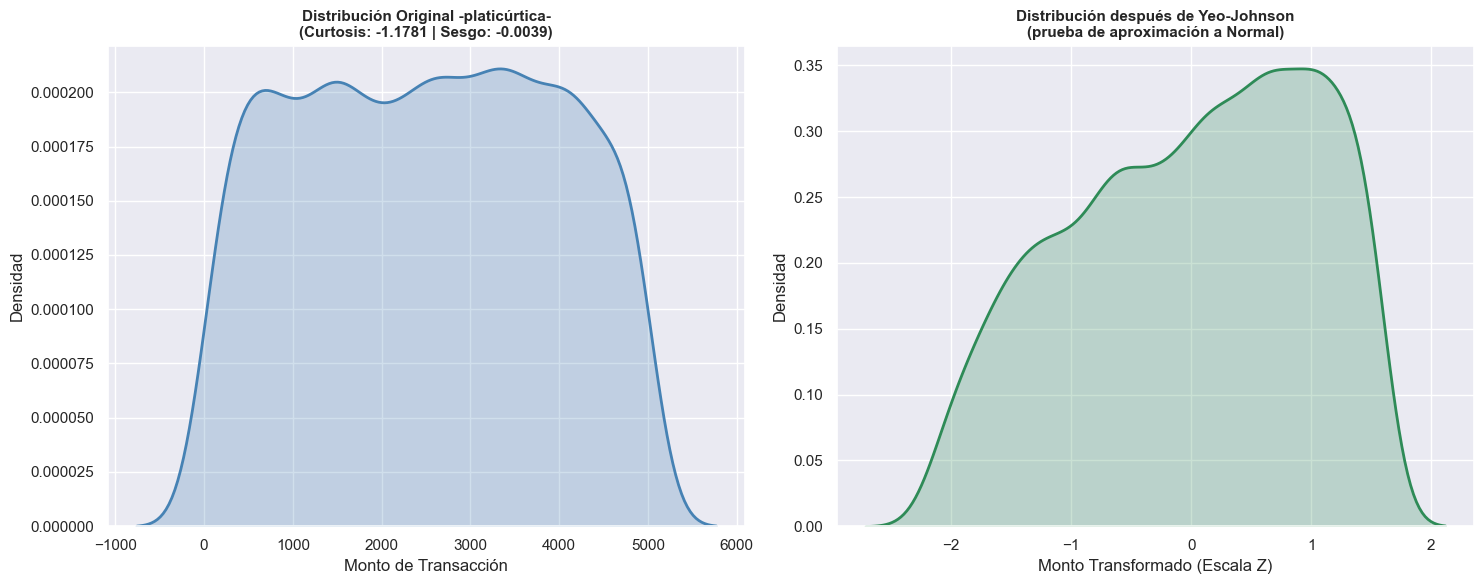

In [159]:
# Aplicar como alternativa una transformación Yeo-Johnson
 
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
subset_bancos['Amount_Transformado'] = pt.fit_transform(subset_bancos[['Transaction_Amount']])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualizar de forma comparativa
# --- GRÁFICO 1: Datos Originales ---
sns.kdeplot(
    data=subset_bancos, 
    x='Transaction_Amount', 
    fill=True, 
    color="#4682B4", 
    linewidth=2, 
    ax=axes[0]
)
axes[0].set_title('Distribución Original -platicúrtica-\n(Curtosis: -1.1781 | Sesgo: -0.0039)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Monto de Transacción')
axes[0].set_ylabel('Densidad')

# --- GRÁFICO 2: Datos Transformados ---
sns.kdeplot(
    data=subset_bancos, 
    x='Amount_Transformado', 
    fill=True, 
    color="#2E8B57", # Color verde para diferenciarlo
    linewidth=2, 
    ax=axes[1]
)
axes[1].set_title('Distribución después de Yeo-Johnson\n(prueba de aproximación a Normal)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Monto Transformado (Escala Z)')
axes[1].set_ylabel('Densidad')

# 3. Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

**Alternativa de Transformación de Transaction_Amount**   
<p align="justify">
Como alternativa para normalizar la serie 'Transaction_Amount', se aplicó una transformación Yeo-Johnson; de la cual se obtuvieron los resultados que se muestran en la gráfica precedente y que coinciden y constatan lo manifestado para la transformación Logarítmica.  
En virtud de lo cual, se procedió a realizar una prueba de distribución uniforme.
</p>

In [ ]:
# Prueba de Distribución Uniforme
minto_min = subset_bancos['Transaction_Amount'].min()
monto_max = subset_bancos['Transaction_Amount'].max()

# loc es el mínimo y scale es el ancho del rango (Máximo - Mínimo)
loc_unif = minto_min
scale_unif = monto_max - minto_min

# Ejecutar la prueba formal de Kolmogorov-Smirnov contra la hipótesis uniforme
# stats.uniform es la distribución rectangular teórica
ks_stat_unif, p_value_unif = stats.kstest(
    subset_bancos['Transaction_Amount'],
    'uniform',
    args=(loc_unif, scale_unif)
)

print("=" * 76)
print("Prueba de BONDAD DE AJUSTE en una DISTRIBUCIÓN UNIFORME -Kolmogorov-Smirnov-")
print("=" * 76)
print()
print(f"   - Rango Teórico Evaluado   : [${loc_unif:,.2f} a ${monto_max:,.2f}]")
print(f"   - Estadístico KS (Uniforme): {ks_stat_unif:.4f}")
print(f"   - p-value (Uniforme)       : {p_value_unif:.4f}")
print()
print("." * 76)
print()

if p_value_unif > 0.05:
    print("   - Conclusión\n     No rechazo H0. Se confirma científicamente que los montos\n     siguen una distribución uniforme (p > 0.05).")
else:
    print("   - Conclusión\n     Rechazo H0. Los datos tampoco son uniformes.")

print()
print("." * 76)


Prueba de BONDAD DE AJUSTE en una DISTRIBUCIÓN UNIFORME -Kolmogorov-Smirnov-

   - Rango Teórico Evaluado   : [$5.46 a $4,999.54]
   - Estadístico KS (Uniforme): 0.0116
   - p-value (Uniforme)       : 0.4584

............................................................................

   - Conclusión
     No rechazo H0. Se confirma científicamente que los montos
     siguen una distribución uniforme (p > 0.05).

............................................................................


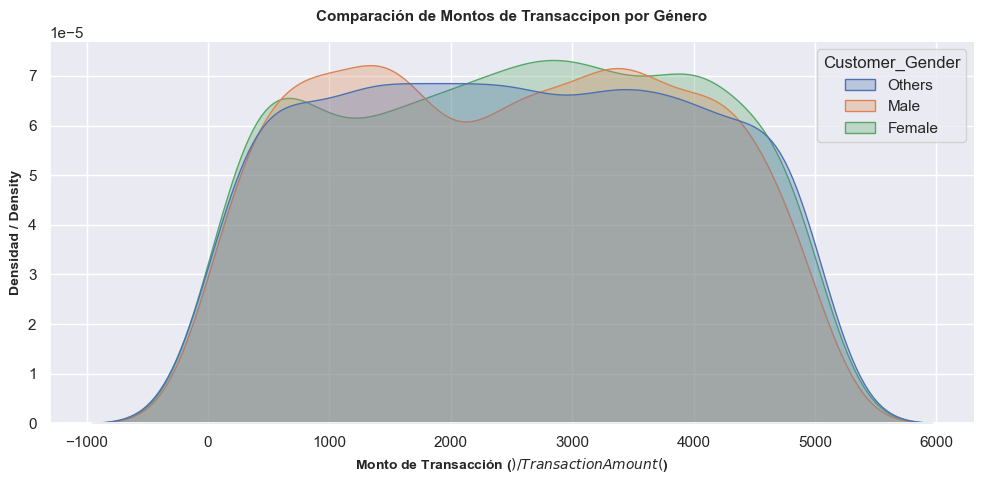

In [160]:
# Análisis de Montos de Transacción por Género
plt.figure(figsize=(10, 5))

# densidad de montos dividida por las categorías de género
sns.kdeplot(data=subset_bancos, x="Transaction_Amount", hue="Customer_Gender", fill=True, alpha=0.3)

plt.title('Comparación de Montos de Transaccipon por Género',
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# PRUEBA INFERENCIAL: MANN-WHITNEY (Hombres vs Mujeres)
# Filtrar los montos
monto_male = subset_bancos[subset_bancos['Customer_Gender'] == 'Male']['Transaction_Amount']
monto_female = subset_bancos[subset_bancos['Customer_Gender'] == 'Female']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_female, monto_male, alternative='two-sided')

print("=" * 111)
print("PRUEBA INFERENCIAL - Comparativa de Montos de Transacción por Género")
print("=" * 111)
print()
print(f"   - Estadístico U : {stat:,.1f}")
print(f"   - p-value       : {p_value:.4f}")
print()
print("." * 111)
print()

if p_value < 0.05:
    print("   - Conclusión\n     Se rechaza H0. Existe una diferencia estadísticamente significativa entre hombres y mujeres.")
else:
    print("   - Conclusión\n     No se rechaza H0. No hay evidencia para afirmar que el género motive variación en los montos a transferir.")

print()
print("." * 111)


PRUEBA INFERENCIAL - Comparativa de Montos de Transacción por Género

   - Estadístico U : 1,653,703.5
   - p-value       : 0.2266

...............................................................................................................

   - Conclusión
     No se rechaza H0. No hay evidencia para afirmar que el género motive variación en los montos a transferir.

...............................................................................................................


In [170]:
# #
# print("""
# ==============================================================================
# CONCLUSIONES FORMALES \nPRUEBA GÉNERO
# ==============================================================================
#   Hallazgo de Negocio
#   La prueba U de Mann-Whitney arrojó un p-valor de 0.2266,
#   lo que confirma que no existe ninguna diferencia significativa entre el dinero
#   que gasta un hombre frente a una mujer.

#   Interpretación Estadística: Al ser el p-valor superior al umbral de 0.05,
#   se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las
#   poblaciones de ambos géneros comparten la misma distribución de gasto uniforme
# """)


# MUESTREO

**Comparativo de Montos de Transacción por Género**   
<p align="justify">
Hallazgo de negocio.- La prueba U de Mann-Whitney arrojó un p-value de 0.2266, lo que confirma que no existe diferencia significativa entre los importes de las operaciones bancarias que realizan las mujeres con respecto a las de los hombres.  

Intepretación Estadística.- Al resultar el p-value superior al umbral de 0.05, se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las poblaciones de ambos géneros comparten la misma distribución en la realización de operaciones bancarias.
</p>

## Muestreo de transacciones y observación inicial

In [ ]:
np.random.seed(123)

print("Muestra aleatoria de 20 transacciones")
df_bancos_sample_20 = df_bancos.sample(n=20, random_state=123)
print(df_bancos_sample_20[["Transaction_Amount"]])

print("\nDescripción de la muestra de 20 registros para Transaction_Amount")
print(df_bancos_sample_20["Transaction_Amount"].describe())

Muestra aleatoria de 20 transacciones
      Transaction_Amount
2075             2814.81
3169             4397.27
4557             1247.57
3040             3311.79
4154             1245.05
4141             2936.20
4523              498.27
4345             4024.52
558              3914.26
1748              694.72
1103             3328.38
1738               99.59
220              4843.70
1621             4024.42
1532             2458.54
2827             4912.92
4357             4735.05
1577             3200.77
4497                8.60
990              2077.35

Descripción de la muestra de 20 registros para Transaction_Amount
count      20.000000
mean     2738.689000
std      1623.890696
min         8.600000
25%      1246.940000
50%      3068.485000
75%      4024.445000
max      4912.920000
Name: Transaction_Amount, dtype: float64


In [ ]:
print("Frecuencias de Fraud_Flag en una muestra de 40 registros")
print(df_bancos.sample(n=40, random_state=123)["Fraud_Flag"].value_counts())

print("\nProporciones de Fraud_Flag en una muestra de 40 registros")
print(df_bancos.sample(n=40, random_state=123)["Fraud_Flag"].value_counts(normalize=True))

print("\nFrecuencias de City en una muestra de 100 registros")
print(df_bancos.sample(n=100, random_state=123)["City"].value_counts())

print("\nProporciones de City en una muestra de 100 registros")
print(df_bancos.sample(n=100, random_state=123)["City"].value_counts(normalize=True))

print("\nFrecuencias totales de City en el conjunto de datos completo")
print(df_bancos["City"].value_counts())

Frecuencias de Fraud_Flag en una muestra de 40 registros
Fraud_Flag
Yes    23
No     17
Name: count, dtype: int64

Proporciones de Fraud_Flag en una muestra de 40 registros
Fraud_Flag
Yes    0.575
No     0.425
Name: proportion, dtype: float64

Frecuencias de City en una muestra de 100 registros
City
San Jose        14
San Antonio     13
Houston         12
Chicago         11
San Diego       10
Dallas          10
New York         9
Los Angeles      8
Phoenix          7
Philadelphia     6
Name: count, dtype: int64

Proporciones de City en una muestra de 100 registros
City
San Jose        0.14
San Antonio     0.13
Houston         0.12
Chicago         0.11
San Diego       0.10
Dallas          0.10
New York        0.09
Los Angeles     0.08
Phoenix         0.07
Philadelphia    0.06
Name: proportion, dtype: float64

Frecuencias totales de City en el conjunto de datos completo
City
Chicago         589
New York        565
San Jose        555
Los Angeles     554
San Antonio     548
Dallas        

## Construcción de la distribución muestral de la proporción de fraude

In [ ]:
samples500 = pd.concat([
    df_bancos.sample(20, random_state=123 + n).assign(replicate=n)
    for n in range(500)
], ignore_index=True)

print("Primeras filas de la tabla de muestras repetidas (samples500)")
print(samples500.head())

Primeras filas de la tabla de muestras repetidas (samples500)
                         Transaction_ID      Account_Number  \
0  89207bc4-8439-4ed9-9a64-845ef49816ad  QALX14120074045156   
1  4f7f963e-d3c5-44a3-8c0b-200d3edec38e  ARDB35743189100492   
2  362465c1-0dd8-463b-b6a2-bf6979315fc6  VPSO93892694813352   
3  077d8688-59fe-4c45-abac-7bf82f4ddc9b  FVZR83149141011201   
4  0bd18d4a-4cf4-4edd-bf93-04fa00059b9d  ZGZS90497910303379   

      Transaction_Date  Transaction_Amount              Merchant_Name  \
0  2024-09-16 13:48:24             2814.81                  Jones-Gay   
1  2024-02-17 06:08:06             4397.27  Butler, Matthews and Levy   
2  2023-03-08 00:34:45             1247.57                 Osborn Ltd   
3  2023-03-01 22:56:01             3311.79       Lee, Miller and Neal   
4  2024-10-16 01:29:32             1245.05                  Green Inc   

  Transaction_Type     Category          City Country   Payment_Method  ...  \
0           Credit    Utilities  Philadel

Distribución muestral de la proporción de fraude (Yes)
   replicate Fraud_Flag  Proporción muestral
0          0        Yes                 0.60
3          1        Yes                 0.50
4          2        Yes                 0.65
6          3        Yes                 0.60
8          4        Yes                 0.60


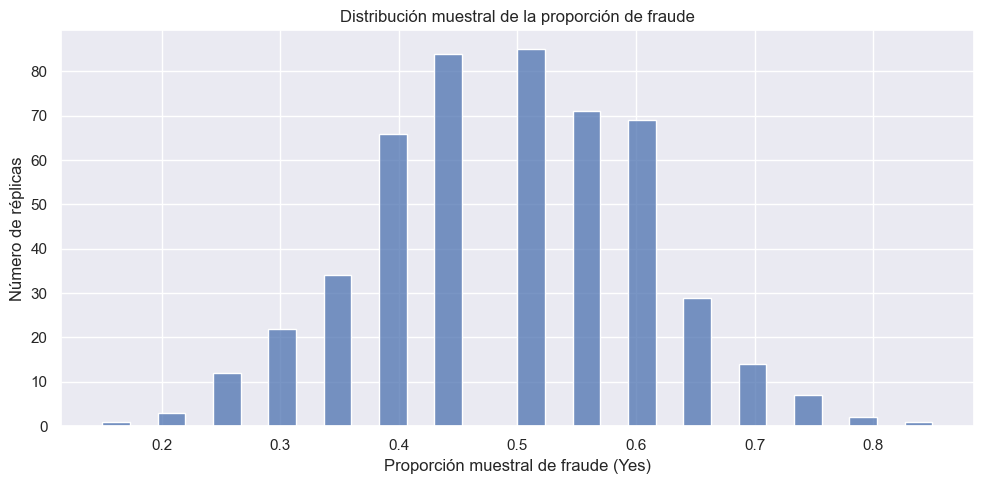

Análisis: la gráfica muestra la variabilidad de la proporción de casos de fraude en muestras de 20 transacciones.
Con n=20, el estimador de proporción aún tiene alta dispersión y cada réplica puede diferir notablemente.
Esto ilustra que, aunque la muestra refleja posible presencia de fraude, la estabilidad solo mejora con muchas réplicas o tamaños de muestra mayores.


In [ ]:
sample_est = (
    samples500
    .groupby("replicate")["Fraud_Flag"]
    .value_counts(normalize=True)
    .reset_index(name="Proporción muestral")
)
sample_est_yes = sample_est[sample_est["Fraud_Flag"] == "Yes"].copy()

print("Distribución muestral de la proporción de fraude (Yes)")
print(sample_est_yes.head())

plt.figure(figsize=(10, 5))
sns.histplot(data=sample_est_yes, x="Proporción muestral", bins=30, kde=False, color="#4C72B0")
plt.title("Distribución muestral de la proporción de fraude")
plt.xlabel("Proporción muestral de fraude (Yes)")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la gráfica muestra la variabilidad de la proporción de casos de fraude en muestras de 20 transacciones.")
print("Con n=20, el estimador de proporción aún tiene alta dispersión y cada réplica puede diferir notablemente.")
print("Esto ilustra que, aunque la muestra refleja posible presencia de fraude, la estabilidad solo mejora con muchas réplicas o tamaños de muestra mayores.")

In [ ]:
print("Estimador puntual de la proporción de fraude en las réplicas")
print(sample_est_yes["Proporción muestral"].mean())

print("\nProporción real de fraude en la población df_bancos")
print(df_bancos["Fraud_Flag"].value_counts(normalize=True))

Estimador puntual de la proporción de fraude en las réplicas
0.4915

Proporción real de fraude en la población df_bancos
Fraud_Flag
No     0.506959
Yes    0.493041
Name: proportion, dtype: float64


## Intervalo de confianza para la proporción de fraude

In [ ]:
ci_data = pd.DataFrame(sample_est_yes["Proporción muestral"])
confidence = 0.95
df_t = len(ci_data) - 1
mean_prop = ci_data["Proporción muestral"].mean()
std_err = ci_data["Proporción muestral"].std(ddof=1) / np.sqrt(len(ci_data))
ci = stats.t.interval(confidence, df_t, loc=mean_prop, scale=std_err)

print("Intervalo de confianza 95% para la proporción de fraude (muestras)")
print(ci)
print("Análisis: el intervalo de confianza cuantifica la incertidumbre del estimador de proporción de fraude construido a partir de las réplicas.")
print("Se utiliza t de Student porque el estimador se basa en muestras y la desviación estándar se estima a partir de los datos.")
print("Si la proporción poblacional cae dentro del intervalo, la muestra es consistente con el comportamiento observado en toda la cartera.")

Intervalo de confianza 95% para la proporción de fraude (muestras)
(np.float64(0.48151709912879903), np.float64(0.501482900871201))
Análisis: el intervalo de confianza cuantifica la incertidumbre del estimador de proporción de fraude construido a partir de las réplicas.
Se utiliza t de Student porque el estimador se basa en muestras y la desviación estándar se estima a partir de los datos.
Si la proporción poblacional cae dentro del intervalo, la muestra es consistente con el comportamiento observado en toda la cartera.


## Distribución de Transaction_Amount en la población y en una muestra

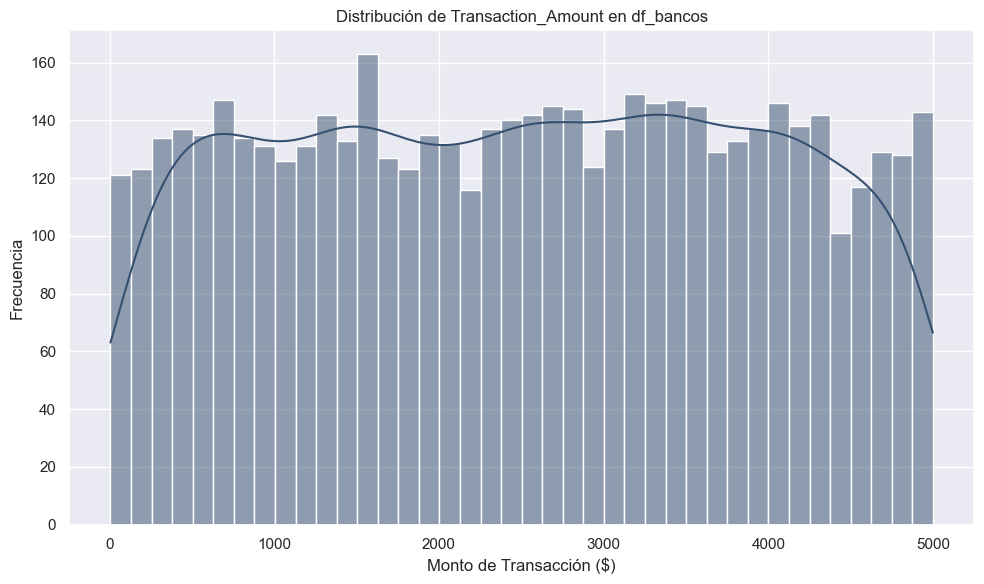

Análisis: el histograma de la población completa permite identificar la forma general de la distribución, su asimetría y los rangos de mayor concentración.
En este dataset, se puede comprobar si los montos se acumulan en un rango reducido o si existen colas largas hacia montos altos.
Esta visión es esencial para interpretar los resultados de muestreo y bootstrap con base en el comportamiento real de los datos.


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos, x="Transaction_Amount", bins=40, kde=True, color="#355070")
plt.title("Distribución de Transaction_Amount en df_bancos")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: el histograma de la población completa permite identificar la forma general de la distribución, su asimetría y los rangos de mayor concentración.")
print("En este dataset, se puede comprobar si los montos se acumulan en un rango reducido o si existen colas largas hacia montos altos.")
print("Esta visión es esencial para interpretar los resultados de muestreo y bootstrap con base en el comportamiento real de los datos.")

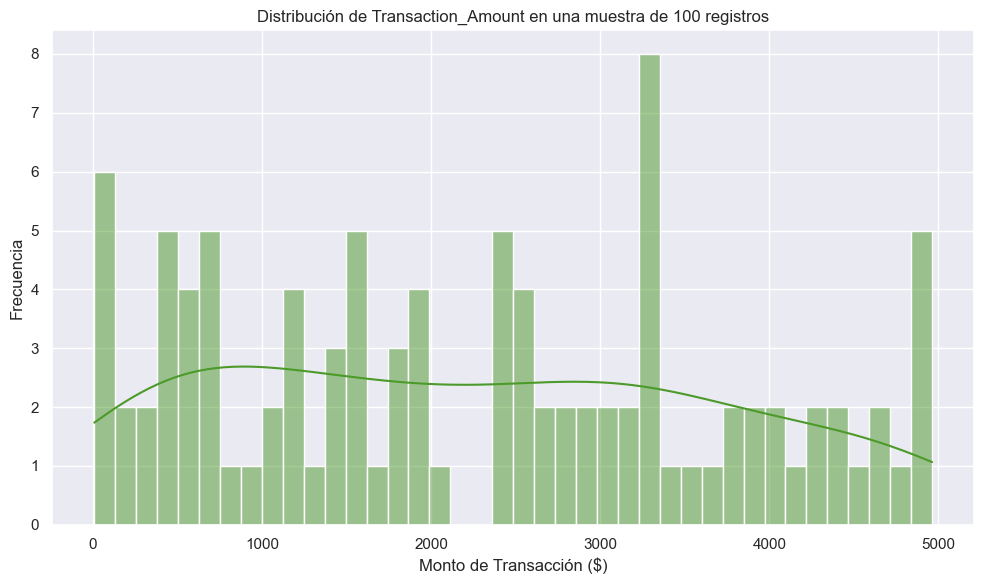

Análisis: la muestra de 100 registros preserva la forma global de la población pero introduce mayor ruido en los detalles locales.
Esta comparación entre población y muestra deja claro que un muestreo aislado puede parecer representativo, pero no captura todas las fluctuaciones reales.
Por eso es importante usar métodos de remuestreo como bootstrap y generar intervalos de confianza que describan la incertidumbre.
Media de la muestra de 100 registros: 2244.5015


In [ ]:
df_bancos_one_sample = df_bancos.sample(n=100, random_state=123)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos_one_sample, x="Transaction_Amount", bins=40, kde=True, color="#4C9A2A")
plt.title("Distribución de Transaction_Amount en una muestra de 100 registros")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: la muestra de 100 registros preserva la forma global de la población pero introduce mayor ruido en los detalles locales.")
print("Esta comparación entre población y muestra deja claro que un muestreo aislado puede parecer representativo, pero no captura todas las fluctuaciones reales.")
print("Por eso es importante usar métodos de remuestreo como bootstrap y generar intervalos de confianza que describan la incertidumbre.")
print("Media de la muestra de 100 registros:", df_bancos_one_sample["Transaction_Amount"].mean())

## Distribución muestral de la media y la varianza de Transaction_Amount

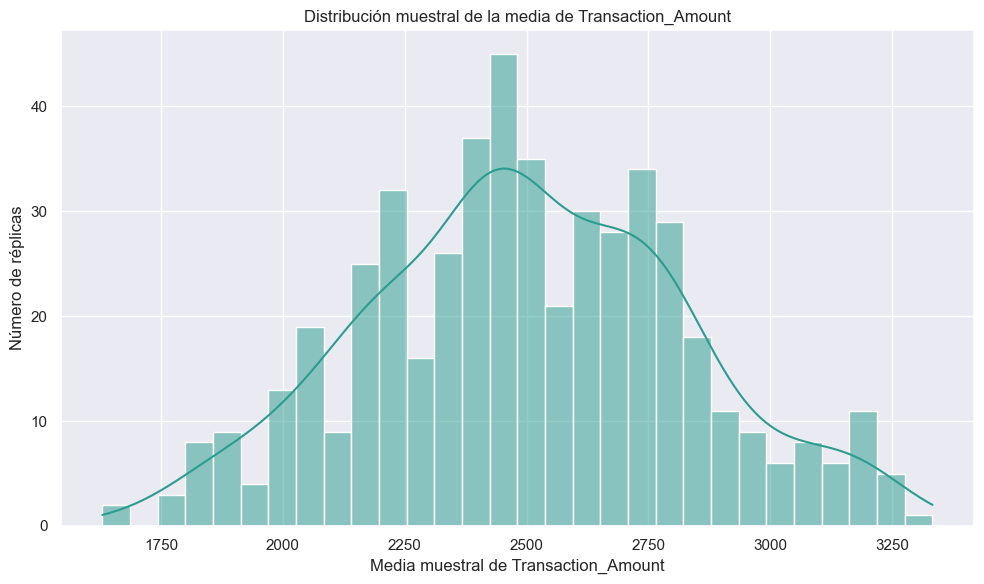

Análisis: la distribución de medias muestrales se concentra alrededor de un valor central, lo que ejemplifica la estabilidad del promedio frente a la variabilidad de las muestras.
Esta concentración es una forma práctica de observar el principio de estabilidad del estimador de la media.
Media de las medias muestrales: 2498.601295


In [ ]:
trans_estimates = (
    samples500
    .groupby("replicate")["Transaction_Amount"]
    .mean()
    .reset_index(name="Transacciones")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=trans_estimates, x="Transacciones", bins=30, kde=True, color="#2A9D8F")
plt.title("Distribución muestral de la media de Transaction_Amount")
plt.xlabel("Media muestral de Transaction_Amount")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la distribución de medias muestrales se concentra alrededor de un valor central, lo que ejemplifica la estabilidad del promedio frente a la variabilidad de las muestras.")
print("Esta concentración es una forma práctica de observar el principio de estabilidad del estimador de la media.")
print("Media de las medias muestrales:", trans_estimates["Transacciones"].mean())

In [ ]:
data1 = pd.DataFrame(trans_estimates["Transacciones"])
df_t2 = len(data1) - 1
mean2 = data1["Transacciones"].mean()
std_err2 = data1["Transacciones"].std(ddof=1) / np.sqrt(len(data1))
ci2 = stats.t.interval(confidence, df_t2, loc=mean2, scale=std_err2)

print("Intervalo de confianza 95% de la media muestral:")
print(ci2)
print("Interpretación: el intervalo refleja cuán precisas son nuestras estimaciones de media cuando el muestreo se repite 500 veces.")

Intervalo de confianza 95% de la media muestral:
(np.float64(2469.692983248197), np.float64(2527.509606751803))
Interpretación: el intervalo refleja cuán precisas son nuestras estimaciones de media cuando el muestreo se repite 500 veces.


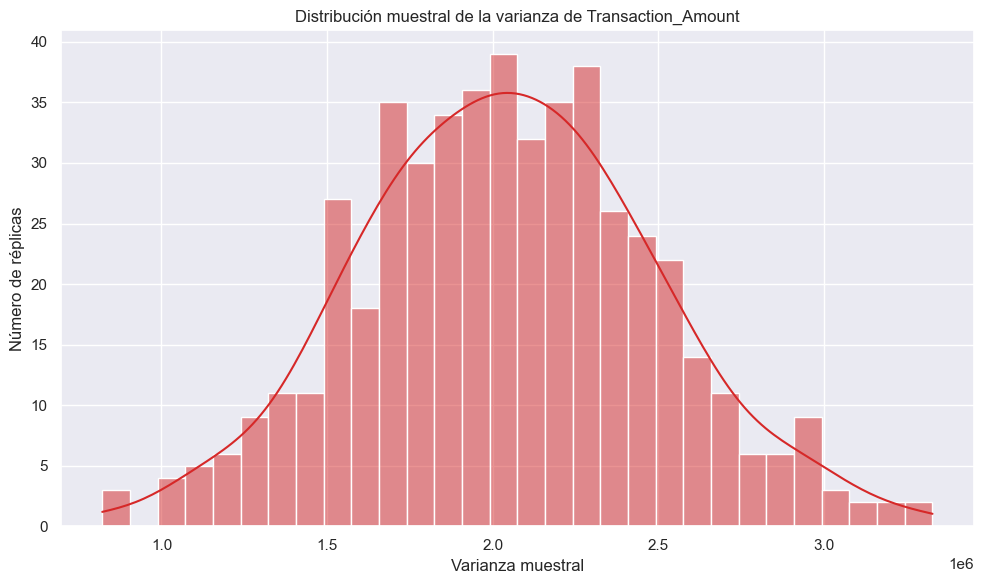

Análisis: la varianza muestral describe la dispersión de los estimadores entre réplicas y ayuda a evaluar cuánta incertidumbre tiene el cálculo del promedio.
Media de la varianza muestral: 2041517.8497833482
Varianza poblacional de Transaction_Amount (ddof=0): 2035223.8900259144


In [ ]:
trans_estimates1 = (
    samples500
    .groupby("replicate")["Transaction_Amount"]
    .var()
    .reset_index(name="var_trans")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=trans_estimates1, x="var_trans", bins=30, kde=True, color="#D62828")
plt.title("Distribución muestral de la varianza de Transaction_Amount")
plt.xlabel("Varianza muestral")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la varianza muestral describe la dispersión de los estimadores entre réplicas y ayuda a evaluar cuánta incertidumbre tiene el cálculo del promedio.")
print("Media de la varianza muestral:", trans_estimates1["var_trans"].mean())
print("Varianza poblacional de Transaction_Amount (ddof=0):", np.var(df_bancos["Transaction_Amount"], ddof=0))

In [ ]:
data_var = pd.DataFrame(trans_estimates1["var_trans"])
alpha = 0.05
n = len(data_var)
var_mean = data_var["var_trans"].mean()
chi2_lower = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_lower = (n - 1) * var_mean / chi2_upper
ci_upper = (n - 1) * var_mean / chi2_lower
print(f"Intervalo de confianza 95% de la varianza muestral: ({ci_lower:.4f}, {ci_upper:.4f})")
print("Interpretación: este intervalo demuestra la incertidumbre asociada al estimador de varianza sobre múltiples réplicas.")

Intervalo de confianza 95% de la varianza muestral: (1810121.5717, 2320551.2440)
Interpretación: este intervalo demuestra la incertidumbre asociada al estimador de varianza sobre múltiples réplicas.


## Bootstrap clásico y estimación empírica

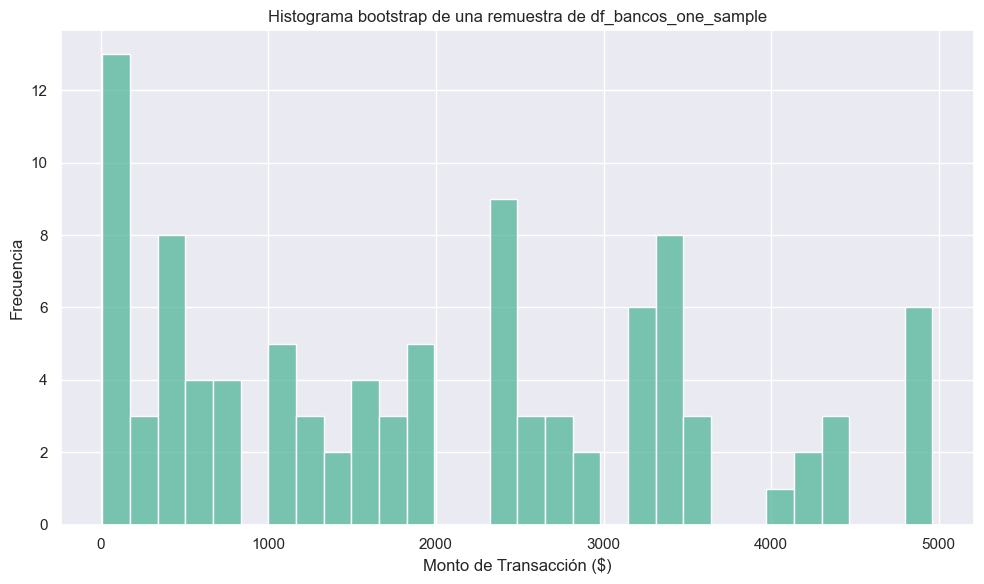

Análisis: la remuestra bootstrap reproduce la muestra base con reemplazo para estimar directamente la variabilidad del estadístico sin suponer una forma teórica.


In [ ]:
boot_trans = df_bancos_one_sample.sample(frac=1, replace=True, random_state=123)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_trans, x="Transaction_Amount", bins=30, kde=False, color="#52B69A")
plt.title("Histograma bootstrap de una remuestra de df_bancos_one_sample")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: la remuestra bootstrap reproduce la muestra base con reemplazo para estimar directamente la variabilidad del estadístico sin suponer una forma teórica.")

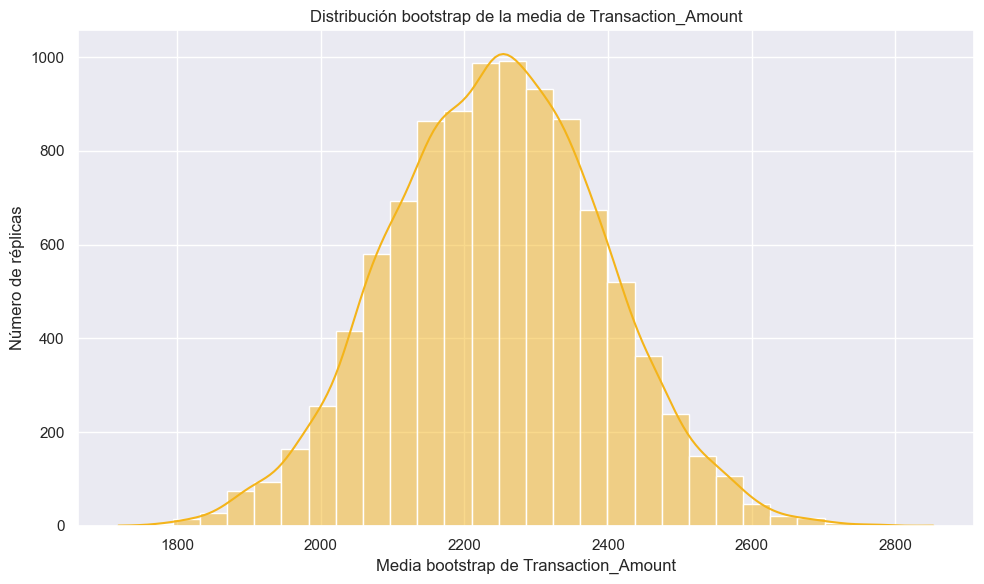

Análisis: la distribución bootstrap de medias muestra cómo el estimador cambia cuando repetimos la remuestreo 10,000 veces.
A diferencia del intervalo paramétrico, este enfoque empírico no asume normalidad en los montos de transacción.
Media bootstrap de 10,000 réplicas: 2244.44968683
Intervalo de confianza empírico bootstrap de la media:
0.025    1955.534972
0.975    2538.001745
Name: Transacciones, dtype: float64
Interpretación: el intervalo empírico bootstrap se calcula directamente desde la distribución de estadísticas bootstrap y refleja la variabilidad real observada.


In [ ]:
boot_trans_10000 = pd.concat([
    df_bancos_one_sample.sample(frac=1, replace=True, random_state=123 + n).assign(replicate=n)
    for n in range(10000)
], ignore_index=True)

boot_charges_10000_means = (
    boot_trans_10000
    .groupby("replicate")["Transaction_Amount"]
    .mean()
    .reset_index(name="Transacciones")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_charges_10000_means, x="Transacciones", bins=30, kde=True, color="#F4B41A")
plt.title("Distribución bootstrap de la media de Transaction_Amount")
plt.xlabel("Media bootstrap de Transaction_Amount")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la distribución bootstrap de medias muestra cómo el estimador cambia cuando repetimos la remuestreo 10,000 veces.")
print("A diferencia del intervalo paramétrico, este enfoque empírico no asume normalidad en los montos de transacción.")
print("Media bootstrap de 10,000 réplicas:", boot_charges_10000_means["Transacciones"].mean())

ci_boot_charges = boot_charges_10000_means["Transacciones"].quantile([0.025, 0.975])
print("Intervalo de confianza empírico bootstrap de la media:")
print(ci_boot_charges)
print("Interpretación: el intervalo empírico bootstrap se calcula directamente desde la distribución de estadísticas bootstrap y refleja la variabilidad real observada.")

## Bootstrap del VaR 95% y comparación con el percentil poblacional

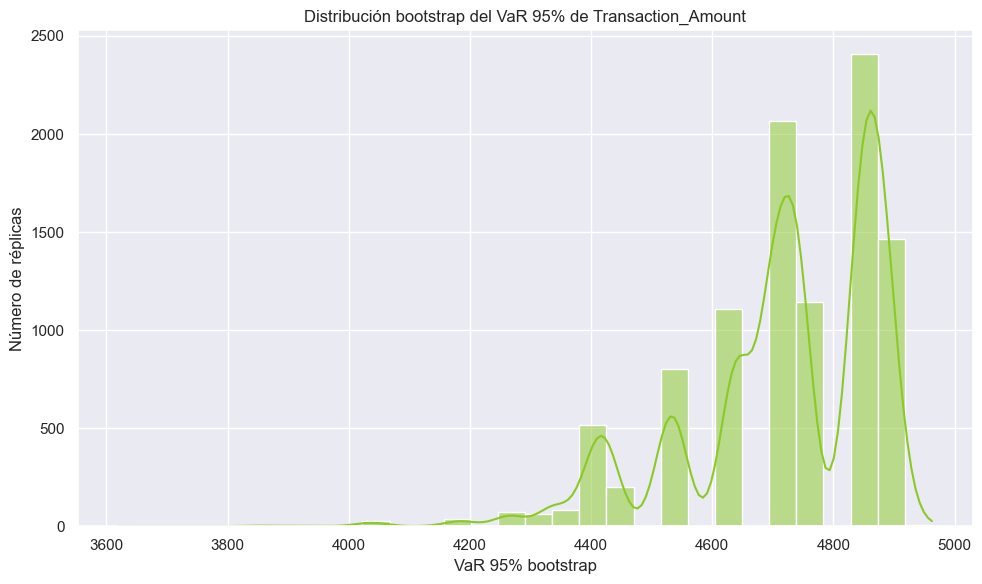

Análisis: el VaR bootstrap captura el valor extremo que no se supera en el 95% de las réplicas, lo cual es una estimación de riesgo de cola.
Esta métrica permite evaluar la exposición a montos altos y su consistencia frente a la variación muestral.
Media bootstrap del VaR 95%: 4717.4044616
Intervalo de confianza empírico bootstrap del VaR 95%:
0.025    4342.3485
0.975    4888.7805
Name: VaR_trans, dtype: float64
Percentil 95 real en la población df_bancos: 4751.092
Interpretación: comparar el VaR bootstrap con el percentil poblacional ayuda a ver si el método bootstrap reproduce correctamente el riesgo extremo observado en los datos completos.
Si hay discrepancia, puede indicar que la muestra base no es completamente representativa del comportamiento de cola de la población.


In [ ]:
boot_trans_10000_VaR = (
    boot_trans_10000
    .groupby("replicate")["Transaction_Amount"]
    .quantile(0.95)
    .reset_index(name="VaR_trans")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_trans_10000_VaR, x="VaR_trans", bins=30, kde=True, color="#8AC926")
plt.title("Distribución bootstrap del VaR 95% de Transaction_Amount")
plt.xlabel("VaR 95% bootstrap")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: el VaR bootstrap captura el valor extremo que no se supera en el 95% de las réplicas, lo cual es una estimación de riesgo de cola.")
print("Esta métrica permite evaluar la exposición a montos altos y su consistencia frente a la variación muestral.")
print("Media bootstrap del VaR 95%:", boot_trans_10000_VaR["VaR_trans"].mean())

ci_boot_trans_VaR = boot_trans_10000_VaR["VaR_trans"].quantile([0.025, 0.975])
print("Intervalo de confianza empírico bootstrap del VaR 95%:")
print(ci_boot_trans_VaR)

print("Percentil 95 real en la población df_bancos:", np.percentile(df_bancos["Transaction_Amount"], 95))

print("Interpretación: comparar el VaR bootstrap con el percentil poblacional ayuda a ver si el método bootstrap reproduce correctamente el riesgo extremo observado en los datos completos.")
print("Si hay discrepancia, puede indicar que la muestra base no es completamente representativa del comportamiento de cola de la población.")

# Ajuste de Distribuciones Teóricas

Utilizando la librería `phitter`, se evalúa de forma automatizada qué modelo probabilístico continuo presenta el mejor ajuste matemático para los datos de la columna `Transaction_Amount`.

In [ ]:
# Ajuste de distribuciones a nuestros datos
phi = phitter.Phitter(data=df_bancos["Transaction_Amount"])
#
phi.fit(n_workers=4)

# Mejor ajuste
phi.best_distribution

{'id': 'uniform',
 'parameters': {'a': np.float64(5.45999999), 'b': np.float64(4999.54000001)}}

In [ ]:
#
phi.summarize()

,distribution,aic,bic,parameters,chi_square,kolmogorov_smirnov,anderson_darling
0,uniform,91789.539505,91802.723735,"a: 5.46, b: 5000",✖️,✅,✅
1,bradford,91791.532093,91811.308438,"c: -0.005151, min: 5.459, max: 5000",✖️,✅,✅
2,beta,91795.950905,91822.319366,"alpha: 1.032, beta: 1.031, A: 5.46, B: 5000",✖️,✅,✅
3,kumaraswamy,91835.856070,91862.224531,"alpha: 1.048, beta: 1.044, min: -10.08, max: 5008",✖️,✅,✅
4,trapezoidal,91997.520403,92023.888864,"a: 5.459, b: 61.74, c: 4952, d: 5000",✖️,✅,✅
5,dagum_4p,91512.703917,91539.072377,"a: 148.2, b: 5021, p: 0.00709, loc: -36.44",✖️,✅,✖️
6,johnson_sb,91896.818404,91923.186864,"xi: -24.67, lambda: 5061, gamma: -0.0004668, d...",✖️,✅,✖️
7,generalized_gamma,12950.472158,12970.248503,"a: 2522, d: 1.941, p: 1.668",✖️,✖️,✖️
8,half_normal,91563.771662,91576.955892,"mu: 616.2, sigma: 2367",✖️,✖️,✖️
9,generalized_normal,91791.539941,91811.316286,"beta: 3.015e+08, mu: 2502, alpha: 2497",✖️,✖️,✖️


In [ ]:
#
phi.df_sorted_distributions.head(10)

distribution passed           aic           bic  \
                                                           
0             uniform      ✅  91789.539505  91802.723735   
1            bradford      ✅  91791.532093  91811.308438   
2                beta      ✅  91795.950905  91822.319366   
3         kumaraswamy      ✅  91835.856070  91862.224531   
4         trapezoidal      ✅  91997.520403  92023.888864   
5            dagum_4p      ✅  91512.703917  91539.072377   
6          johnson_sb      ✅  91896.818404  91923.186864   
7   generalized_gamma     ✖️  12950.472158  12970.248503   
8         half_normal     ✖️  91563.771662  91576.955892   
9  generalized_normal     ✖️  91791.539941  91811.316286   

                                          parameters     chi_square  \
                                                     test_statistic   
0                                   a: 5.46, b: 5000      23.667471   
1                c: -0.005151, min: 5.459, max: 5000      23.653671   
2        alpha: 1.032, beta: 1.031, A: 5.46, B: 5000      20.238687   
3  alpha: 1.048, beta: 1.044, min: -10.08, max: 5008      20.648975   
4               a: 5.459, b: 61.74, c: 4952, d: 5000      21.735139   
5         a: 148.2, b: 5021, p: 0.00709, loc: -36.44      29.065301   
6  xi: -24.67, lambda: 5061, gamma: -0.0004668, d...      43.319765   
7                        a: 2522, d: 1.941, p: 1.668    1575.377841   
8                             mu: 616.2, sigma: 2367    1424.948724   
9             beta: 3.015e+08, mu: 2502, alpha: 2497            NaN   

                                    kolmogorov_smirnov                 \
  critical_value   p_value rejected     test_statistic critical_value   
0      21.026070  0.022565     True           0.011610       0.018469   
1      19.675138  0.014275     True           0.011902       0.018469   
2      18.307038  0.027074     True           0.007487       0.018469   
3      18.307038  0.023679     True           0.007052       0.018469   
4      18.307038  0.016512     True           0.008154       0.018469   
5      18.307038  0.001216     True           0.015776       0.018469   
6      18.307038  0.000004     True           0.017581       0.018469   
7      19.675138  0.000000     True           0.081716       0.018469   
8      21.026070  0.000000     True           0.204271       0.018469   
9            NaN       NaN     None           0.499814       0.018469   

                     anderson_darling                                        
    p_value rejected   test_statistic critical_value       p_value rejected  
0  0.458440    False         0.893546        2.49227  4.182430e-01    False  
1  0.426711    False         0.883365        2.49227  4.246368e-01    False  
2  0.920900    False         0.475642        2.49227  7.717590e-01    False  
3  0.949738    False         0.413246        2.49227  8.354925e-01    False  
4  0.863181    False         1.899006        2.49227  1.044493e-01    False  
5  0.135298    False         2.648122        2.49227  4.146123e-02     True  
6  0.070642    False         3.196805        2.49227  2.177058e-02     True  
7  0.000000     True       120.598016        2.49227  1.113379e-07     True  
8  0.000000     True              NaN            NaN           NaN     None  
9  0.000000     True      2078.974341        2.49227  1.113379e-07     True

In [ ]:
# Parametros de la dustrución que mejor ajustó
#
phi.get_parameters("uniform")

{'a': np.float64(5.45999999), 'b': np.float64(4999.54000001)}

In [ ]:
phi.plot_histogram()

In [ ]:
# Histograma con las distribuciones superpuestas

phi.plot_histogram_distributions()

In [ ]:
#Función de distribución de nuestros datos
phi.plot_ecdf()

In [ ]:
#Funciones de distribución superpuestas: Nuestros datos vs. uniform
phi.plot_ecdf_distribution("uniform")

In [ ]:
# Con línea de regresión de ajuste
phi.qq_plot_regression("uniform")

# Estimación del Value at Risk (VaR 95%)

Se calcula el VaR al 95% utilizando dos metodologías distintas para medir la pérdida o exposición máxima esperada en las transacciones bancarias:

1. **VaR Empírico:** Calculado directamente a partir de los datos históricos reales mediante percentiles numéricos.
2. **VaR Teórico (Distribución Uniforme):** Basado en los parámetros óptimos de localización y escala obtenidos en el ajuste probabilístico.


## Estimación Puntual e Intervalos de Confianza

* **VaR por Simulación (Uniforme):** Genera múltiples réplicas sintéticas basadas en el modelo ajustado.
* **VaR por Bootstrap:** Remuestrea directamente los datos históricos con reemplazo.
* **Intervalos de Confianza (95%):** Delimitan los límites inferior (percentil 2.5) y superior (percentil 97.5) de la variabilidad del riesgo simulado.


In [ ]:
# VaR empírico al 95% para los montos de transacciones bancarias
VaR_empirico = np.percentile(df_bancos["Transaction_Amount"], 95)
print(f"VaR Empírico (95%): {VaR_empirico}")


VaR Empírico (95%): 4751.092


In [ ]:
# parametros obtenidos por phitter
a_param = 5.45999999
b_param = 4999.54000001

#
loc_param = a_param
scale_param = b_param - a_param

# Calcular el percentil 95 (VaR 95%)
VaR_uniforme = uniform.ppf(0.95, loc=loc_param, scale=scale_param)
print(f"VaR Uniforme (Teórico): {VaR_uniforme}")


VaR Uniforme (Teórico): 4749.836000009


In [ ]:

# Parámetros óptimos obtenidos por phitter
a_param = 5.45999999
b_param = 4999.54000001

loc_param = a_param
scale_param = b_param - a_param

# Lista para almacenar los VaR simulados
VaR_uniforme_sim = []

# Simulación de Monte Carlo (5000 iteraciones)
for i in range(5000):
    # Genera 500 muestras aleatorias bajo la distribución uniforme y calcula su percentil 95
    muestras = uniform.rvs(loc=loc_param, scale=scale_param, size=500)
    VaR_uniforme_sim.append(np.percentile(muestras, 95))

# Mostrar los primeros 5 resultados simulados
print(VaR_uniforme_sim[:5])


[np.float64(4735.733624479348), np.float64(4770.5898273191015), np.float64(4766.909459425369), np.float64(4728.999003285872), np.float64(4683.3246419522975)]


In [ ]:
# Estimador puntual del VaR simulado
print("VaR Uniforme Promedio:", np.mean(VaR_uniforme_sim))


VaR Uniforme Promedio: 4740.662340474863


In [ ]:
# Estimador puntual (El VaR promedio obtenido en las simulaciones)
var_promedio = np.mean(VaR_uniforme_sim)
print(f"VaR Uniforme Promedio: {var_promedio:.4f}")

# Intervalo de confianza al 95% para nuestra estimación del VaR
ci_lower = np.percentile(VaR_uniforme_sim, 2.5)
ci_upper = np.percentile(VaR_uniforme_sim, 97.5)

print(f"95% Confidence Interval for 95% VaR: [{ci_lower:.4f}, {ci_upper:.4f}]")


VaR Uniforme Promedio: 4740.6623
95% Confidence Interval for 95% VaR: [4634.1292, 4826.3910]


In [ ]:
# VaR por Bootstrap para transacciones bancarias
VaR_boot = []

for i in range(5000):
    #
    muestra_bootstrap = df_bancos["Transaction_Amount"].sample(frac=1, replace=True)

    #
    VaR_boot.append(np.percentile(muestra_bootstrap, 95))

print(VaR_boot[:5])


[np.float64(4781.428), np.float64(4732.03), np.float64(4765.32), np.float64(4740.68), np.float64(4772.1219999999985)]


In [ ]:
# Estimador puntual promedio obtenido mediante Bootstrap
var_boot_promedio = np.mean(VaR_boot)
print(f"VaR Bootstrap Promedio: {var_boot_promedio:.4f}")

# 95% boot Confidence Interval for our VaR estimate
ci_lower = np.percentile(VaR_boot, 2.5)
ci_upper = np.percentile(VaR_boot, 97.5)

print(f"95% Bootstrap Confidence Interval for 95% VaR: [{ci_lower:.4f}, {ci_upper:.4f}]")


VaR Bootstrap Promedio: 4754.0144
95% Bootstrap Confidence Interval for 95% VaR: [4729.6215, 4788.7440]
